# Prototype LiDAR Pipeline v3

**Key change from v2: Pre-trigger background**

Each profile has **1024 pre-trigger bins** (range 0–3840 m) before the laser return starts.
Background is computed from the **pre-trigger region (0–3800 m)** of the glued signal,
then the pre-trigger is saved as a separate CSV and removed from the signal.

**Processing order:**
1. Convert DAT → CSV
2. Add `bin_index`, `range_m`, SNR
3. Dead-time correction on raw `photon_counting`
4. Overlap regression in signal region: x=`analog`, y=`photon_deadtime` → `k_scale`, `b_offset`
5. `analog_scaled_for_glue = k * analog + b`
6. Toggle-rate-based gluing → `merged_raw` (applied to **all** bins including pre-trigger)
7. **Compute background** = mean of `merged_raw` in pre-trigger region (0–3800 m)
8. **Save pre-trigger CSV** (bins 0–1023) per timestamp
9. **Cut pre-trigger** — keep signal only (range ≥ 3840 m)
10. Background subtraction: `merged_bg_corr = merged_raw − bg_pretrigger`
11. Afterpulse correction on `merged_bg_corr`
12. Range² correction → normalize → `range2_norm`
13. Save signal per-timestamp CSV and wide CSV

In [2]:
import re
import csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
DAYS = [
    "25-03-2026",
    "26-03-2026",
    # "04-02-2026",
    # "05-02-2026",
    # "06-02-2026",
]

BASE_DIR = Path("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile")
CSV_BASE  = Path("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles")
CSV_BASE.mkdir(exist_ok=True)

config = {
    "bin_width_ns":        25,
    "bin_spacing_m":       3.75,
    "prf_hz":              20,
    "dead_time_ns":        3.06,
    # ── Pre-trigger ───────────────────────────────────────────────
    "pretrigger_bins":     1024,   # first 1024 bins = pre-trigger
    "pretrigger_bg_end_m": 3800,   # use 0–3800 m for bg (avoid laser near 3840 m)
    "signal_start_m":      3840,   # 1024 × 3.75 m = 3840 m
    # ── Regression window = toggle window (counts/bin converted from MHz) ──
    # Regression is done on bins where photon_deadtime ∈ [min, max] toggle window
    # This is the region where both detectors operate in their linear regime
    "max_toggle_mhz":      10.0,
    "min_toggle_mhz":      0.5,
    "afterpulse_provided": True,
}
bin_spacing_m = config["bin_spacing_m"]

def make_time_tags():
    return [f"{hh:02d}.{mm:02d}" for hh in range(24) for mm in (5, 35)]

In [3]:
# Load afterpulse profile (set to None if not available)
AfterPulse = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/AfterPulse.csv")

## Part 1 — Convert DAT files to CSV

In [5]:
float_re = re.compile(r"""^[\s+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?$""")

def is_number(tok):
    return bool(float_re.match(tok))

def convert_one_time_tag(day, time_tag):
    DAT_DIR = BASE_DIR / f"{day}-DATfile"
    OUT_DIR = CSV_BASE / day
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    infile  = DAT_DIR / f"{time_tag}.dat"
    outfile = OUT_DIR  / f"{time_tag}.csv"
    if not infile.exists():
        print(f"[SKIP] {day} {time_tag}")
        return
    rows = []
    with infile.open("r", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5 and all(is_number(p) for p in parts):
                rows.append([float(p) for p in parts])
    if not rows:
        print(f"[WARN] Empty {day} {time_tag}")
        return
    with outfile.open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["analog", "analog_sterr", "photon_counting", "pc_sterr", "overflow_info"])
        w.writerows(rows)
    print(f"[OK] {day} {time_tag}: {len(rows)} rows → {outfile}")

for day in DAYS:
    print(f"\n=== {day} ===")
    for time_tag in make_time_tags():
        convert_one_time_tag(day, time_tag)


=== 25-03-2026 ===
[OK] 25-03-2026 00.05: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/00.05.csv
[OK] 25-03-2026 00.35: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/00.35.csv
[OK] 25-03-2026 01.05: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/01.05.csv
[OK] 25-03-2026 01.35: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/01.35.csv
[OK] 25-03-2026 02.05: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/02.05.csv
[OK] 25-03-2026 02.35: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/02.35.csv
[OK] 25-03-2026 03.05: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/03.05.csv
[OK] 25-03-2026 03.35: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/03.35.csv
[OK] 25-03-2026 04.05: 5024 rows → /Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/04.05.csv
[OK] 25-03-2026 04.35: 5024 rows → 

## Part 2 — Load CSVs

In [7]:
day_dfs = {}

for day in DAYS:
    day_dir = CSV_BASE / day
    if not day_dir.exists():
        print(f"[SKIP] {day}")
        continue
    dfs = []
    for csv_path in sorted(day_dir.glob("*.csv")):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df["day"]      = day
        df["time_tag"] = csv_path.stem
        dfs.append(df)
    if dfs:
        day_dfs[day] = pd.concat(dfs, ignore_index=True)
        print(f"[OK] {day}: {len(day_dfs[day])} rows")

day_dfs[DAYS[0]].head()

[OK] 25-03-2026: 241152 rows
[OK] 26-03-2026: 241152 rows


,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,day,time_tag
0,5.67941,0.000580,0.033361,0.023509,0.0,25-03-2026,00.05
1,5.67969,0.000553,0.016681,0.016695,0.0,25-03-2026,00.05
2,5.67959,0.000552,0.000000,0.000000,0.0,25-03-2026,00.05
3,5.67965,0.000538,0.000000,0.000000,0.0,25-03-2026,00.05
4,5.67970,0.000545,0.016681,0.016695,0.0,25-03-2026,00.05


## Part 3 — Pipeline Functions

### Step 2: bin_index, range_m, SNR

In [9]:
def add_bin_and_snr_day(df, *, bin_spacing_m):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["bin_index"] = df.groupby(["day", "time_tag"]).cumcount()
    df["range_m"]   = df["bin_index"] * bin_spacing_m
    df["SNR_analog"] = df["analog"]          / df["analog_sterr"]
    df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]
    main_cols = ["day", "time_tag", "bin_index", "range_m",
                 "analog", "analog_sterr", "photon_counting", "pc_sterr",
                 "overflow_info", "SNR_analog", "SNR_Photon"]
    extra = [c for c in df.columns if c not in main_cols]
    return df[[c for c in main_cols if c in df.columns] + extra]

### Step 3: Dead-time correction

In [11]:
def add_deadtime_day(df, *, config):
    """
    Non-paralyzable dead-time correction on raw photon_counting.
    N = S / (1 + S·τ_D)  →  S = N / (1 - N·τ_D/T)
    NaN where ratio ≥ 1 (detector saturated).
    """
    df = df.copy()
    bin_width_s = config["bin_width_ns"] * 1e-9
    dead_time_s = config["dead_time_ns"] * 1e-9
    raw   = df["photon_counting"].to_numpy(dtype=float) * config["bin_width_ns"] * 1e-3
    ratio = raw * dead_time_s / bin_width_s
    df["photon_per_bin_raw"] = raw
    df["photon_deadtime"]    = np.where(ratio < 1, raw / (1.0 - ratio), np.nan)
    return df

### Steps 4–6: Regression → analog_scaled → glue

> Regression uses bins where **`photon_deadtime` is in the toggle window** (`min_toggle_mhz`–`max_toggle_mhz` converted to counts/bin).  
> This is the range where both detectors operate linearly — same approach as the reference pipeline.  
> Glue is applied to **all bins** (including pre-trigger) so the pre-trigger merged signal can be used for background.

In [13]:
def add_glue_merge_day(df, *, config):
    """
    Step 4 — Regression using bins where photon_deadtime is in the toggle window
              (min_toggle_mhz–max_toggle_mhz converted to counts/bin).
              This matches the reference pipeline: regression is done at the
              range where both detectors operate in their linear regime.
              x=analog, y=photon_deadtime → k_scale, b_offset
    Step 5 — analog_scaled_for_glue = k*analog + b
    Step 6 — Toggle-rate blend (per-bin, based on photon_counting MHz):
              photon_counting > max_toggle_mhz → weight_w = 0 (use analog_scaled)
              photon_counting < min_toggle_mhz → weight_w = 1 (use photon_deadtime)
              between min–max            → cosine blend
    Applied to ALL bins (pre-trigger + signal) so pre-trigger merged_raw
    can be used as background reference.
    """
    df = df.copy()
    for col in ["k_scale", "b_offset", "r2_overlap",
                "analog_scaled_for_glue", "weight_w", "merged_raw"]:
        if col not in df.columns:
            df[col] = np.nan

    max_t = config["max_toggle_mhz"]
    min_t = config["min_toggle_mhz"]
    bin_width_ns = config["bin_width_ns"]

    # toggle window in counts/bin (same unit as photon_deadtime)
    max_t_cts = max_t * bin_width_ns * 1e-3
    min_t_cts = min_t * bin_width_ns * 1e-3

    for (day, time_tag), g_idx in df.groupby(["day", "time_tag"]).groups.items():
        g = df.loc[g_idx]

        # ── Regression: bins where photon_deadtime is in the toggle window ────
        m_ov = (
            (g["photon_deadtime"] >= min_t_cts) &
            (g["photon_deadtime"] <= max_t_cts) &
            np.isfinite(g["analog"]) &
            np.isfinite(g["photon_deadtime"])
        )
        go = g.loc[m_ov]

        # Fallback: all finite rows (e.g. daytime when photon is everywhere saturated)
        if len(go) < 2:
            m_fallback = np.isfinite(g["analog"]) & np.isfinite(g["photon_deadtime"])
            go = g.loc[m_fallback]

        if len(go) < 2:
            continue

        x  = go["analog"].to_numpy(dtype=float)
        y  = go["photon_deadtime"].to_numpy(dtype=float)
        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() < 2:
            continue

        k, b = np.polyfit(x[ok], y[ok], 1)
        yhat  = k * x[ok] + b
        ss_res = np.sum((y[ok] - yhat) ** 2)
        ss_tot = np.sum((y[ok] - y[ok].mean()) ** 2)
        r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot

        df.loc[g_idx, "k_scale"]    = k
        df.loc[g_idx, "b_offset"]   = b
        df.loc[g_idx, "r2_overlap"] = r2

        # ── Scaled analog (all bins) ──────────────────────────────────────────
        df.loc[g_idx, "analog_scaled_for_glue"] = k * g["analog"].to_numpy(dtype=float) + b

        # ── Toggle-rate blend weights (based on raw photon_counting in MHz) ───
        pc  = g["photon_counting"].to_numpy(dtype=float)  # MHz
        w   = np.ones_like(pc, dtype=float)               # default: photon_deadtime
        w[pc >= max_t] = 0.0                              # saturated → analog_scaled
        blend = (pc > min_t) & (pc < max_t)
        if blend.any() and (max_t > min_t):
            w[blend] = 0.5 * (1.0 - np.cos(
                np.pi * (max_t - pc[blend]) / (max_t - min_t)
            ))
        df.loc[g_idx, "weight_w"] = w

        # ── Merged (all bins including pre-trigger) ───────────────────────────
        ana_sc   = df.loc[g_idx, "analog_scaled_for_glue"].to_numpy(dtype=float)
        phot_dt  = g["photon_deadtime"].to_numpy(dtype=float)
        df.loc[g_idx, "merged_raw"] = (
            (1.0 - w) * ana_sc
            + w * np.where(np.isfinite(phot_dt), phot_dt, ana_sc)
        )

    return df

### Steps 7–9: Pre-trigger bg → cut → background subtraction → afterpulse → range²

In [15]:
def split_pretrigger_and_apply_bg_day(df, *, config, AfterPulse=None,
                                       pretrigger_out_base="OutputPictCSV"):
    """
    Step 7 — Compute background from pre-trigger region (0–pretrigger_bg_end_m)
             using merged_raw of each timestamp.
    Step 8 — Save pre-trigger rows (range < signal_start_m) to separate CSV.
    Step 9 — Keep signal rows only (range >= signal_start_m).
             Reindex range_m: signal bin 1024 = 0 m (laser fires here).
             range_m_signal = original_range_m - signal_start_m
    Step 10 — Background subtraction: merged_bg_corr = merged_raw − bg_pretrigger
    Step 11 — Afterpulse correction on merged_bg_corr  (optional)
    Step 12 — Range² correction + normalize → range2_norm

    Returns only the signal portion of df, with range_m starting from 0.
    """
    signal_start_m    = config["signal_start_m"]
    pretrigger_bg_end = config["pretrigger_bg_end_m"]
    bin_width_ns      = config["bin_width_ns"]

    # Preload afterpulse array
    ap_raw = None
    if AfterPulse is not None:
        ap_raw = (AfterPulse["afterpulse_raw"].to_numpy()
                  if isinstance(AfterPulse, pd.DataFrame)
                  else np.asarray(AfterPulse))

    signal_parts = []

    for (day, time_tag), g_idx in df.groupby(["day", "time_tag"]).groups.items():
        g = df.loc[g_idx].copy()

        # ── Split ─────────────────────────────────────────────────────────────
        pre_mask = g["range_m"] < signal_start_m
        sig_mask = g["range_m"] >= signal_start_m

        g_pre = g.loc[pre_mask]
        g_sig = g.loc[sig_mask].copy()

        # ── Step 7: background from pre-trigger merged_raw ────────────────────
        bg_mask = (g_pre["range_m"] >= 0) & (g_pre["range_m"] <= pretrigger_bg_end)
        bg_vals = g_pre.loc[bg_mask, "merged_raw"]
        bg_mean = np.nanmean(bg_vals) if not bg_vals.empty else 0.0

        g_sig["bg_pretrigger"] = bg_mean

        # ── Step 8: Save pre-trigger CSV ──────────────────────────────────────
        tttt    = time_tag.replace(".", "").replace(":", "")
        pre_dir = Path(pretrigger_out_base) / f"{day}-{tttt}"
        pre_dir.mkdir(parents=True, exist_ok=True)
        pre_path = pre_dir / f"{day}-{tttt}_pretrigger.csv"
        g_pre.to_csv(pre_path, index=False)

        # ── Step 9: Reindex range_m so signal starts at 0 m ──────────────────
        # bin 1024 is where the laser fires → that is 0 m range
        g_sig["range_m"] = g_sig["range_m"] - signal_start_m

        # ── Step 10: Background subtraction ───────────────────────────────────
        merged = g_sig["merged_raw"].to_numpy(dtype=float)
        merged_bg = merged - bg_mean
        g_sig["merged_bg_corr"] = merged_bg

        # ── Step 11: Afterpulse correction ────────────────────────────────────
        if ap_raw is not None:
            bi    = g_sig["bin_index"].to_numpy().astype(int)
            valid = (bi >= 0) & (bi < len(ap_raw))
            ap_vals  = np.full(len(g_sig), np.nan)
            ap_vals[valid] = ap_raw[bi[valid]]
            ap_counts = ap_vals * bin_width_ns * 1e-3
            g_sig["afterpulse_raw"]            = ap_vals
            g_sig["afterpulse_counts_per_bin"] = ap_counts
            merged_ap = merged_bg - np.where(np.isfinite(ap_counts), ap_counts, 0.0)
        else:
            merged_ap = merged_bg.copy()
        g_sig["merged_APcorr"] = merged_ap

        # ── Step 12: Range² correction + normalize ────────────────────────────
        r  = g_sig["range_m"].to_numpy(dtype=float)
        r2 = merged_ap * (r ** 2)
        g_sig["range2_corrected_counts"] = r2

        mx = np.nanmax(r2)
        g_sig["range2_norm"] = r2 / mx if (np.isfinite(mx) and mx != 0) else 0.0

        signal_parts.append(g_sig)

    if not signal_parts:
        return pd.DataFrame()
    return pd.concat(signal_parts, ignore_index=True)

### Single-profile pipeline (for interactive exploration)

In [17]:
from scipy.stats import linregress


def run_pipeline_single(
    filepath,
    *,
    max_toggle_rate = 10.0,
    min_toggle_rate = 0.5,
    dead_time_ns    = 3.06,
    bin_shift       = 0,
    bg_start_m      = 0.0,
    bg_end_m        = 3750.0,
    energy_mj       = 25.0,
    blend_r1        = 100.0,
    blend_r2        = 400.0,
    bin_spacing_m   = 3.75,
    pretrigger_bins = 1024,
):
    """
    Process a single per-timestamp raw CSV through the full pipeline.

    Parameters
    ----------
    filepath        : path to the raw .csv (5 columns: analog, analog_sterr,
                      photon_counting, pc_sterr, overflow_info)
    max_toggle_rate : above this MHz → use analog_scaled only (weight_w = 0)
    min_toggle_rate : below this MHz → use photon_deadtime only (weight_w = 1)
    dead_time_ns    : detector dead time in nanoseconds
    bin_shift       : shift photon_counting by this many bins before dead-time corr
    bg_start_m      : background region start (pre-trigger, original range_m)
    bg_end_m        : background region end   (pre-trigger, original range_m)
    energy_mj       : laser pulse energy in mJ for NRB normalisation
    blend_r1        : spatial blend start (m, after reindex to 0)
    blend_r2        : spatial blend end   (m, after reindex to 0)

    Returns
    -------
    df_sig      : DataFrame with signal only (range_m starts at 0)
    slope       : regression slope (analog → photon)
    offset      : regression intercept
    fit_quality : R² of regression
    bg_mean     : mean background value subtracted
    """
    signal_start_m = pretrigger_bins * bin_spacing_m  # 1024 × 3.75 = 3840 m

    # ── load & normalise column names ─────────────────────────────────────────
    df = pd.read_csv(filepath)
    df.columns = (
        df.columns.str.strip().str.lower()
        .str.replace(r"[\s\-]+", "_", regex=True)
    )

    # ── bin index & range (original, includes pre-trigger) ────────────────────
    df["bin_index"] = np.arange(len(df))
    df["range_m"]   = df["bin_index"] * bin_spacing_m

    # ── bin shift ─────────────────────────────────────────────────────────────
    df["photon_counting_shifted"] = df["photon_counting"].shift(bin_shift)

    # ── dead-time correction ──────────────────────────────────────────────────
    dead_time_s = dead_time_ns * 1e-9
    rate_hz     = df["photon_counting_shifted"] * 1e6
    ratio       = rate_hz * dead_time_s
    df["photon_deadtime"] = np.where(
        ratio < 1,
        rate_hz / (1.0 - ratio) / 1e6,
        np.nan,
    )

    # ── background from pre-trigger region (original range_m) ────────────────
    bg_mask  = (df["range_m"] >= bg_start_m) & (df["range_m"] <= bg_end_m)
    bg_mean  = np.nanmean(df.loc[bg_mask, "photon_deadtime"])

    # ── cut to signal region & reindex range to 0 ────────────────────────────
    df_sig = df[df["range_m"] >= signal_start_m].copy()
    df_sig["range_m"] = df_sig["range_m"] - signal_start_m

    # ── regression: rows inside toggle window ─────────────────────────────────
    reg_mask = (
        (df_sig["photon_deadtime"] >= min_toggle_rate) &
        (df_sig["photon_deadtime"] <= max_toggle_rate) &
        np.isfinite(df_sig["analog"]) &
        np.isfinite(df_sig["photon_deadtime"])
    )
    reg_data = df_sig.loc[reg_mask, ["analog", "photon_deadtime"]]

    # fallback: all finite rows (e.g. daytime when photon is everywhere saturated)
    if len(reg_data) < 2:
        reg_mask = np.isfinite(df_sig["analog"]) & np.isfinite(df_sig["photon_deadtime"])
        reg_data = df_sig.loc[reg_mask, ["analog", "photon_deadtime"]]

    slope = offset = fit_quality = np.nan
    if len(reg_data) >= 2:
        slope, offset, r_val, *_ = linregress(
            reg_data["analog"].to_numpy(),
            reg_data["photon_deadtime"].to_numpy(),
        )
        fit_quality = r_val ** 2
        df_sig["analog_scaled_for_glue"] = slope * df_sig["analog"] + offset
    else:
        df_sig["analog_scaled_for_glue"] = np.nan

    # ── glue weights (spatial blend) ──────────────────────────────────────────
    r  = df_sig["range_m"].to_numpy()
    pc = df_sig["photon_counting"].to_numpy()

    w = np.ones(len(r), dtype=float)
    m_blend = (r >= blend_r1) & (r <= blend_r2)
    if m_blend.any():
        w[m_blend] = 0.5 * (
            1.0 - np.cos(np.pi * (r[m_blend] - blend_r1) / (blend_r2 - blend_r1))
        )
    w[pc >= max_toggle_rate] = 0.0   # saturated → analog_scaled
    w[pc <= min_toggle_rate] = 1.0   # weak → photon_deadtime

    df_sig["weight_w"]   = w
    df_sig["merged_raw"] = (
        (1.0 - w) * df_sig["analog_scaled_for_glue"]
        + w        * np.where(np.isfinite(df_sig["photon_deadtime"]),
                               df_sig["photon_deadtime"],
                               df_sig["analog_scaled_for_glue"])
    )

    # ── background subtraction ────────────────────────────────────────────────
    df_sig["merged_bg_corr"] = df_sig["merged_raw"] - bg_mean

    # ── range² correction + energy normalisation ──────────────────────────────
    r2 = df_sig["merged_bg_corr"] * (r ** 2)
    df_sig["range2_corrected_counts"] = r2

    e_joule = energy_mj * 1e-3
    nrb     = r2 / e_joule
    df_sig["nrb"] = nrb

    max_val = np.nanmax(nrb)
    df_sig["range2_norm"] = nrb / max_val if (np.isfinite(max_val) and max_val != 0) else np.nan

    return df_sig, slope, offset, fit_quality, bg_mean

## Part 4 — Run Pipeline

In [19]:
day_dfs_signal = {}   # only signal portion (range >= 3840 m)

for day in list(day_dfs.keys()):
    print(f"Processing {day}...", end=" ")

    df = day_dfs[day].copy()

    # Step 2
    df = add_bin_and_snr_day(df, bin_spacing_m=bin_spacing_m)

    # Step 3
    df = add_deadtime_day(df, config=config)

    # Steps 4–6  (regression + glue on all bins)
    df = add_glue_merge_day(df, config=config)

    # Steps 7–12  (pre-trigger bg → cut → bg sub → AP → r²)
    df_sig = split_pretrigger_and_apply_bg_day(
        df,
        config=config,
        AfterPulse=AfterPulse,
        pretrigger_out_base="OutputPictCSV",
    )

    day_dfs_signal[day] = df_sig
    print(f"done — signal rows: {len(df_sig)}, cols: {df_sig.shape[1]}")

print("\nFinal columns:")
print(day_dfs_signal[DAYS[0]].columns.tolist())

Processing 25-03-2026... done — signal rows: 192000, cols: 26
Processing 26-03-2026... done — signal rows: 192000, cols: 26

Final columns:
['day', 'time_tag', 'bin_index', 'range_m', 'analog', 'analog_sterr', 'photon_counting', 'pc_sterr', 'overflow_info', 'SNR_analog', 'SNR_Photon', 'photon_per_bin_raw', 'photon_deadtime', 'k_scale', 'b_offset', 'r2_overlap', 'analog_scaled_for_glue', 'weight_w', 'merged_raw', 'bg_pretrigger', 'merged_bg_corr', 'afterpulse_raw', 'afterpulse_counts_per_bin', 'merged_APcorr', 'range2_corrected_counts', 'range2_norm']


In [20]:
# Quick sanity check — range should start at 0 m after reindex (not 3840 m)
print(f"Range min: {day_dfs_signal[DAYS[0]]['range_m'].min()} m  (expected 0 m)")
print(f"Range max: {day_dfs_signal[DAYS[0]]['range_m'].max()} m  "
      f"(expected {(5024 - config['pretrigger_bins'] - 1) * config['bin_spacing_m']:.2f} m)")
print(f"\nBackground (pretrigger mean) sample:")
day_dfs_signal[DAYS[0]].groupby("time_tag")["bg_pretrigger"].first().head(10)

Range min: 0.0 m  (expected 0 m)
Range max: 14996.25 m  (expected 14996.25 m)

Background (pretrigger mean) sample:


time_tag
00.05    0.000220
00.35    0.000195
01.05    0.000202
01.35    0.000179
02.05    0.000178
02.35    0.000172
03.05    0.000175
03.35    0.000138
04.05    0.000144
04.35    0.000164
Name: bg_pretrigger, dtype: float64

In [21]:
# Regression summary
day = DAYS[0]
summary = (
    day_dfs_signal[day]
    .groupby("time_tag")[["k_scale", "b_offset", "r2_overlap", "bg_pretrigger"]]
    .first()
)
print(summary)

           k_scale   b_offset  r2_overlap  bg_pretrigger
time_tag                                                
00.05     2.521133 -14.317054    0.995425       0.000220
00.35     2.452103 -13.924217    0.992510       0.000195
01.05     2.512855 -14.274435    0.990798       0.000202
01.35     2.482529 -14.096428    0.995467       0.000179
02.05     2.515774 -14.294014    0.994333       0.000178
02.35     2.517506 -14.318198    0.993932       0.000172
03.05     2.497527 -14.193797    0.991586       0.000175
03.35     2.499010 -14.210796    0.993141       0.000138
04.05     2.488050 -14.137722    0.992424       0.000144
04.35     2.509514 -14.253558    0.992698       0.000164
05.05     2.507461 -14.235829    0.993284       0.000147
05.35     2.549626 -14.463349    0.993570       0.000153
06.05     2.508298 -14.235916    0.993118       0.004922
06.35     0.262853  -0.240997    0.603374       1.406604
07.05     0.182203   2.543619    0.744552       3.982491
07.35     0.082776   4.858066  

## Part 5 — Save Outputs

In [23]:
def save_timestamp_csv(df_t, *, day, time_tag, out_base="OutputPictCSV", suffix="processed"):
    tttt    = time_tag.replace(".", "").replace(":", "")
    out_dir = Path(out_base) / f"{day}-{tttt}"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{day}-{tttt}_{suffix}.csv"
    df_t.to_csv(out_path, index=False)
    return out_path


all_saved = []

for day in DAYS:
    if day not in day_dfs_signal:
        continue
    df_day = day_dfs_signal[day]
    for time_tag in sorted(df_day["time_tag"].unique()):
        df_t = df_day[df_day["time_tag"] == time_tag].copy()
        if df_t.empty:
            continue
        path = save_timestamp_csv(df_t, day=day, time_tag=time_tag)
        all_saved.append(path)

print(f"Saved {len(all_saved)} signal timestamp CSV files.")
print(f"Pre-trigger CSVs saved alongside each signal CSV as *_pretrigger.csv")

Saved 96 signal timestamp CSV files.
Pre-trigger CSVs saved alongside each signal CSV as *_pretrigger.csv


In [24]:
def save_day_wide_csv(
    df_day, *, day,
    out_base="OutputPictCSV", subdir="CSVeachday",
    xcol="range_m", tcol="time_tag", vcol="range2_norm", suffix=""
):
    out_dir = Path(out_base) / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    expected_times = [f"{hh:02d}.{mm:02d}" for hh in range(24) for mm in (5, 35)]
    wide = (
        df_day
        .pivot_table(index=xcol, columns=tcol, values=vcol, aggfunc="mean")
        .sort_index()
    )
    wide.columns = wide.columns.astype(str)
    wide = wide.reindex(columns=expected_times)
    wide = wide.apply(pd.to_numeric, errors="coerce")
    wide = wide.reset_index()
    wide = wide[[xcol] + expected_times]
    out_path = out_dir / f"{day}{suffix}.csv"
    wide.to_csv(out_path, index=False)
    return out_path


all_wide = []

for day in DAYS:
    if day not in day_dfs_signal:
        continue
    path = save_day_wide_csv(day_dfs_signal[day], day=day, vcol="range2_norm")
    all_wide.append(path)
    print(f"Saved: {Path(path).resolve()}")

print(f"\nSaved {len(all_wide)} wide CSV files.")

Saved: /Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV/CSVeachday/25-03-2026.csv
Saved: /Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV/CSVeachday/26-03-2026.csv

Saved 2 wide CSV files.


## Part 6 — Curtain Plot

In [26]:
import os
import matplotlib.dates as mdates

SAVE_DIR = "OutputPictCSV/CurtainPlots"


def plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    title="",
    scale="linear",
    save=True,
    save_dir=SAVE_DIR,
    ylim=None,
    xlim=None,
    clim=None,
    cmap="jet",
    invert_y=False,
    pbls=None,
    pbl_style="line",
    pbl_color="white",
    pbl_label="PBL",
    pbl_align="nearest",
    pbl_tol="5min",
    ytick_max=15000,
    ytick_step=3000,
):
    """
    Z          : 2D DataFrame — index = range (m), columns = datetime
    title      : extra string appended to plot title
    scale      : 'linear' or 'log'
    ylim/xlim  : axis limits
    clim       : colour limits (vmin, vmax)
    cmap       : colormap
    pbls       : pd.Series (index=datetime, values=PBL height in metres)
    pbl_align  : 'exact' or 'nearest'
    """
    if scale == "log":
        Z_plot      = np.log10(Z.clip(lower=1e-6))
        color_label = "log\u2081\u2080(Signal)"
        scale_tag   = "log10"
    else:
        Z_plot      = Z.copy()
        color_label = "Signal"
        scale_tag   = "linear"

    fig, ax = plt.subplots(figsize=(14, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns, Z_plot.index, Z_plot.values,
        shading="auto", cmap=cmap
    )

    if clim is not None:
        pcm.set_clim(*clim)

    # ── PBL overlay ───────────────────────────────────────────────────────────
    if pbls is not None:
        pbls = pbls.copy()
        pbls.index = pd.to_datetime(pbls.index, errors="coerce")
        pbls = pbls.dropna()

        Z_cols = pd.to_datetime(Z.columns, errors="coerce")

        if pbl_align == "nearest":
            pbl_line = pbls.reindex(Z_cols, method="nearest",
                                    tolerance=pd.Timedelta(pbl_tol))
        else:
            pbl_line = pbls.reindex(Z_cols)

        pbl_line.index = Z_cols
        pbl_line = pd.to_numeric(pbl_line, errors="coerce")
        pbl_line = pbl_line.where(np.isfinite(pbl_line)).dropna()

        if len(pbl_line) > 0:
            if pbl_style == "scatter":
                ax.scatter(pbl_line.index, pbl_line.values,
                           s=10, color=pbl_color, label=pbl_label, zorder=10)
            else:
                ax.plot(pbl_line.index, pbl_line.values,
                        linewidth=1.5, color=pbl_color,
                        label=pbl_label, zorder=10)
            ax.legend(loc="upper right", fontsize=9)
        else:
            print("\u26a0\ufe0f  PBL: no valid points after alignment")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y\n%H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)
    if invert_y:
        ax.invert_yaxis()

    ax.set_yticks(range(0, ytick_max + 1, ytick_step))

    ax.set_title(
        f"{title} ({scale_tag})  "
        f"{pd.to_datetime(start_date):%d %b %Y} \u2013 "
        f"{pd.to_datetime(end_date):%d %b %Y}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)
    plt.tight_layout()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        fname = (
            f"{title.replace(' ', '_')}_{scale_tag}_"
            f"{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}.png"
        )
        save_path = os.path.join(save_dir, fname)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved \u2192 {save_path}")

    plt.show()

Saved → OutputPictCSV/CurtainPlots/Prototype_v3_25-03-2026_linear_20260325_20260325.png


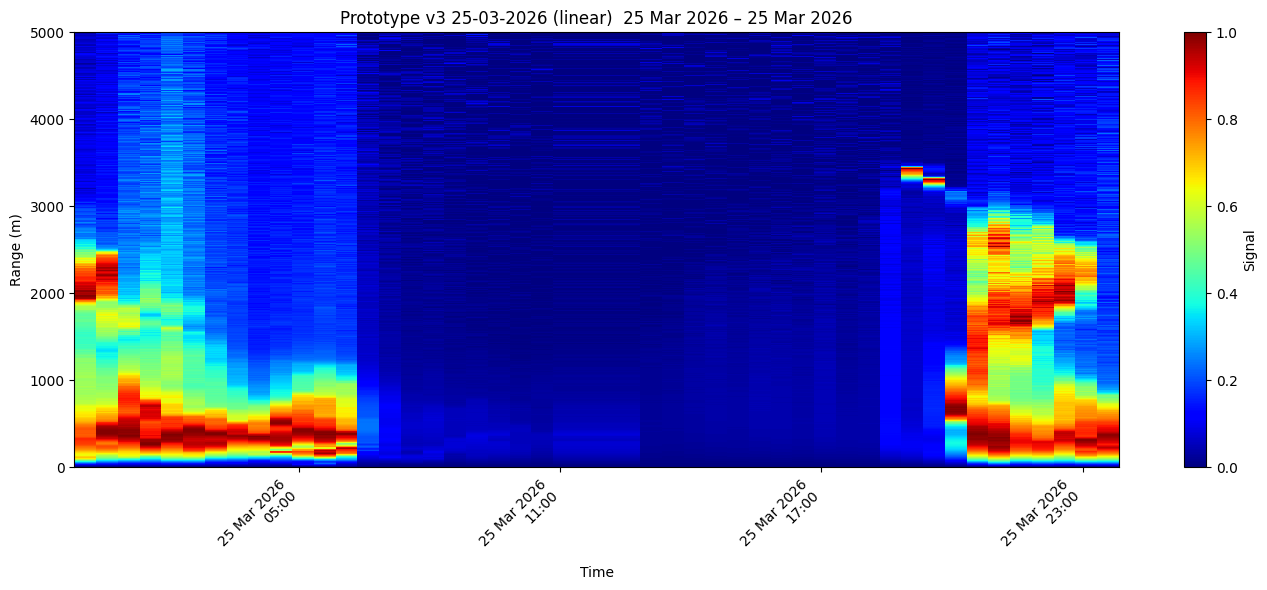

Saved → OutputPictCSV/CurtainPlots/Prototype_v3_25-03-2026_log10_20260325_20260325.png


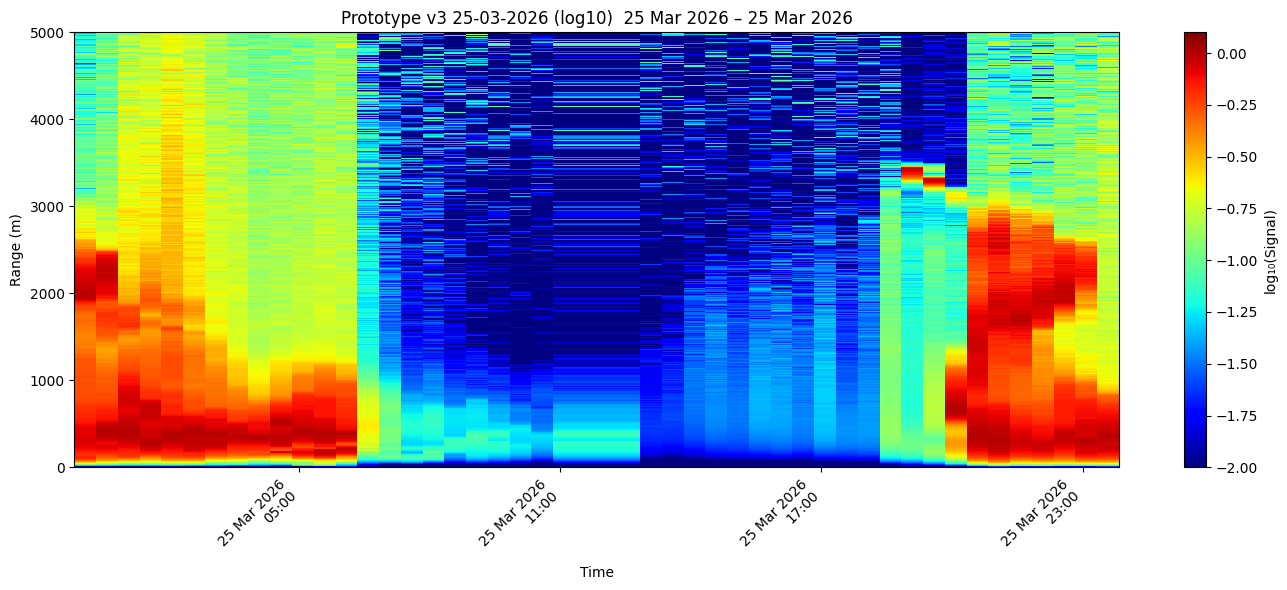

Saved → OutputPictCSV/CurtainPlots/Prototype_v3_26-03-2026_linear_20260326_20260326.png


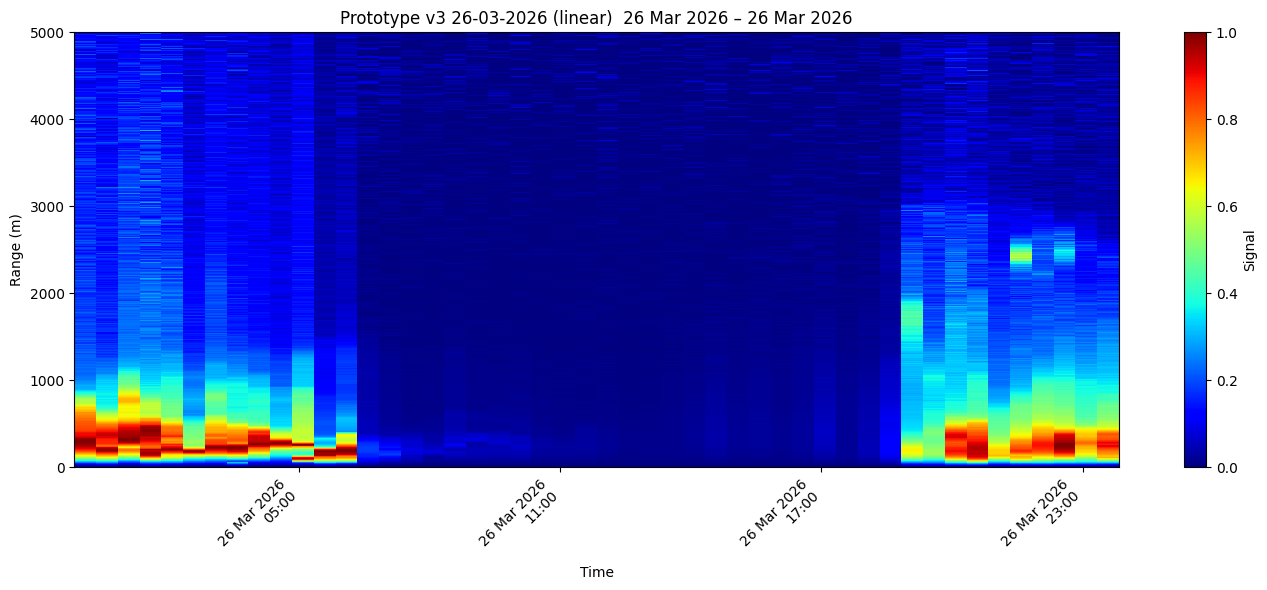

Saved → OutputPictCSV/CurtainPlots/Prototype_v3_26-03-2026_log10_20260326_20260326.png


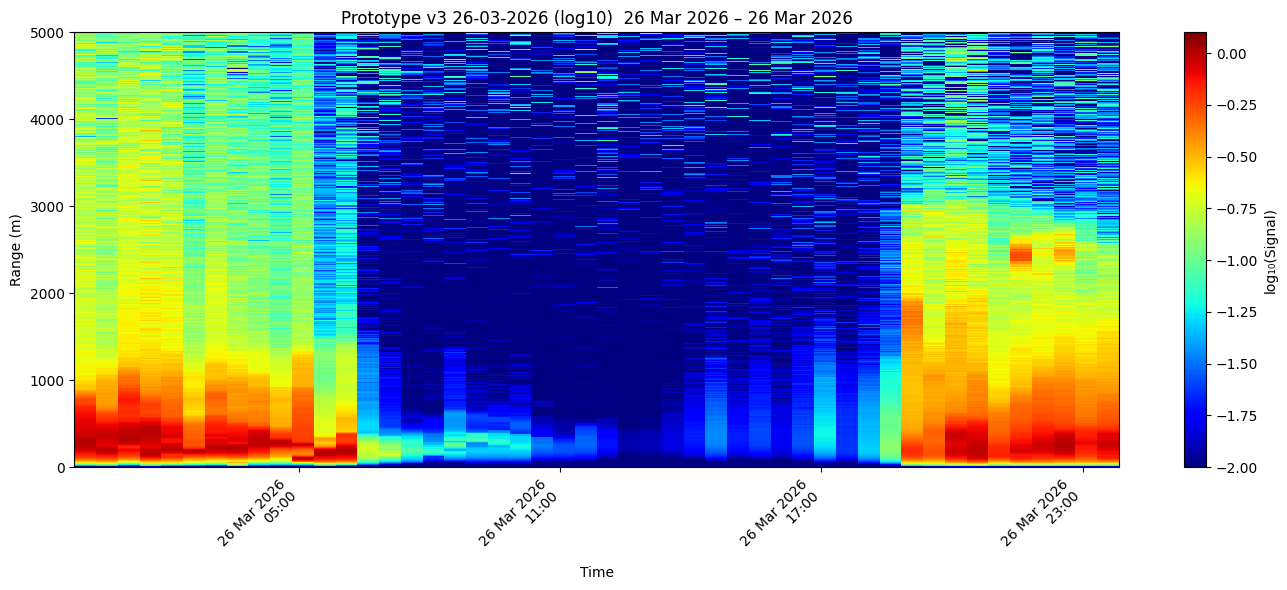

In [27]:
for day in DAYS:
    if day not in day_dfs_signal:
        print(f"[SKIP] {day}")
        continue

    df_day = day_dfs_signal[day]

    # ── Build Z: pivot time_tag → datetime column, range_m as index ──────────
    # Convert time_tag (e.g. "00.05") to full datetime for the x-axis
    date_obj = pd.to_datetime(day, format="%d-%m-%Y")

    def time_tag_to_dt(tt, base_date):
        hh, mm = tt.split(".")
        return base_date.replace(hour=int(hh), minute=int(mm), second=0)

    Z = df_day.pivot_table(
        index="range_m", columns="time_tag",
        values="range2_norm", aggfunc="mean"
    ).sort_index()

    # rename columns to proper datetime
    Z.columns = [time_tag_to_dt(tt, date_obj) for tt in Z.columns]

    start_date = Z.columns[0]
    end_date   = Z.columns[-1]

    # ── Linear scale ──────────────────────────────────────────────────────────
    plot_lidar_curtain(
        Z,
        start_date=start_date,
        end_date=end_date,
        title=f"Prototype v3 {day}",
        scale="linear",
        clim=(0, 1),
        ylim=(0, 5000),
        cmap="jet",
        ytick_max=5000,
        ytick_step=1000,
    )

    # ── Log scale ─────────────────────────────────────────────────────────────
    plot_lidar_curtain(
        Z,
        start_date=start_date,
        end_date=end_date,
        title=f"Prototype v3 {day}",
        scale="log",
        clim=(-2, 0.1),
        ylim=(0, 5000),
        cmap="jet",
        ytick_max=5000,
        ytick_step=1000,
    )


📅 25-03-2026: plotting 48 profiles


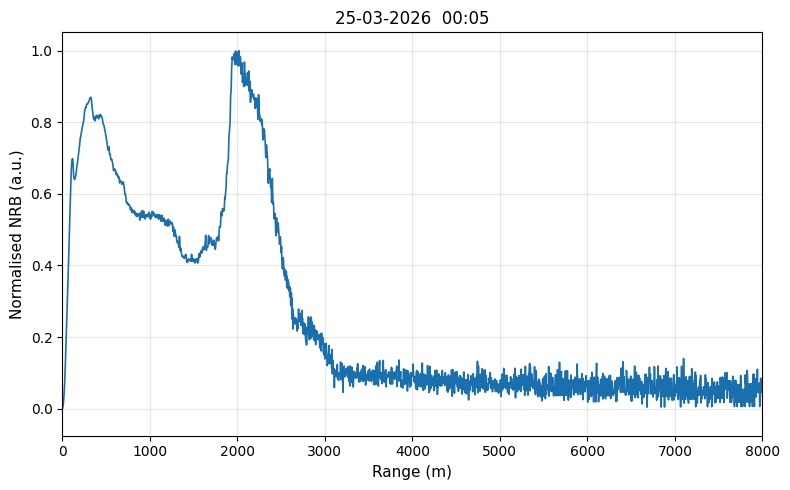

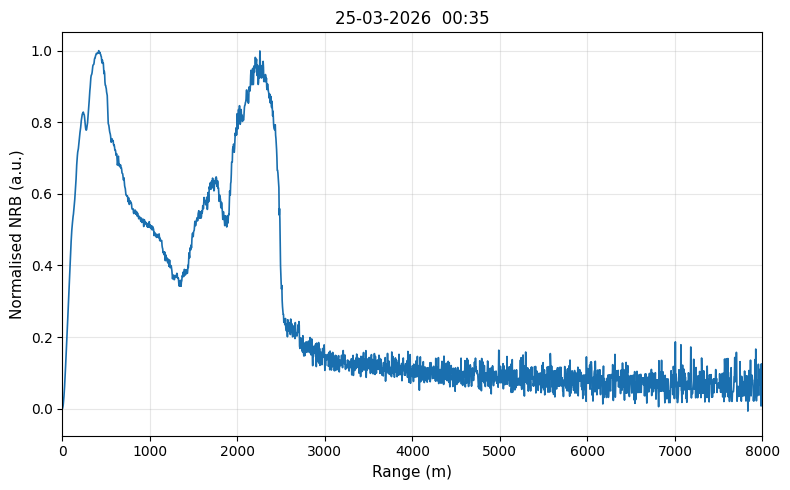

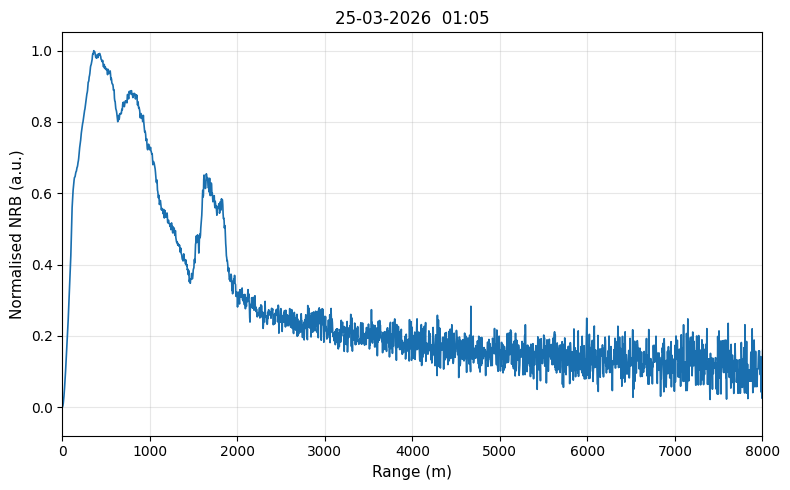

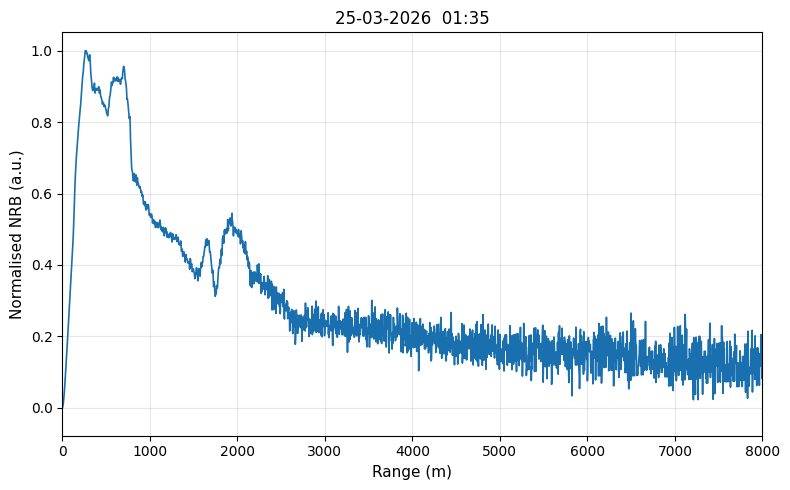

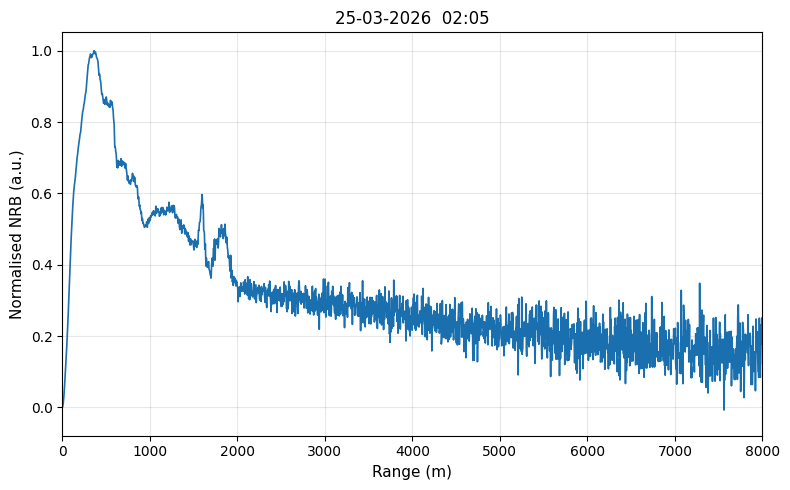

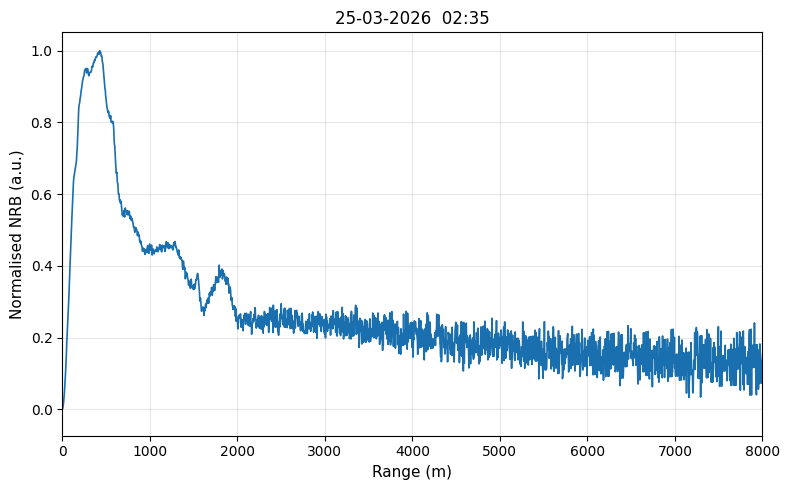

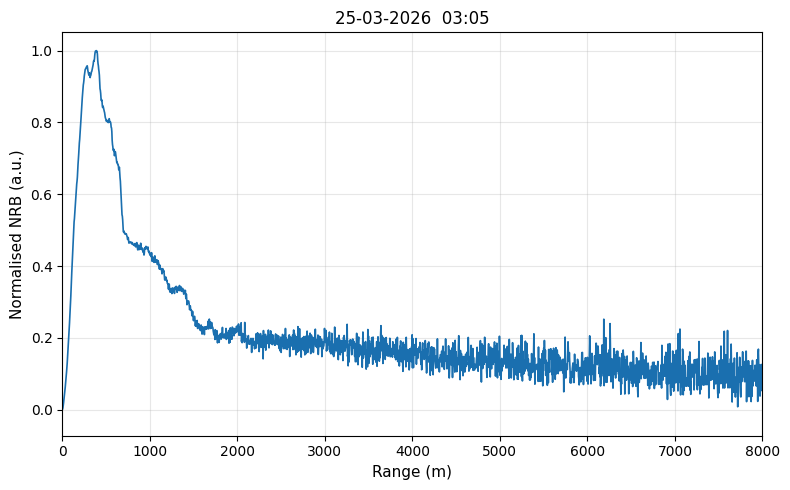

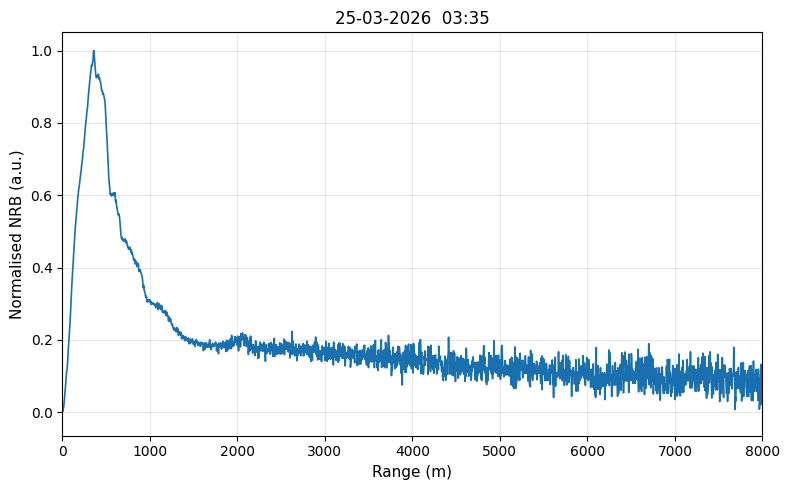

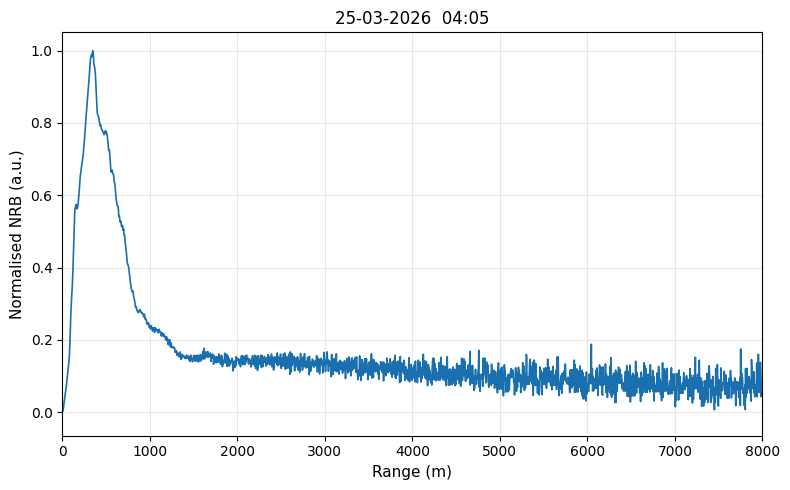

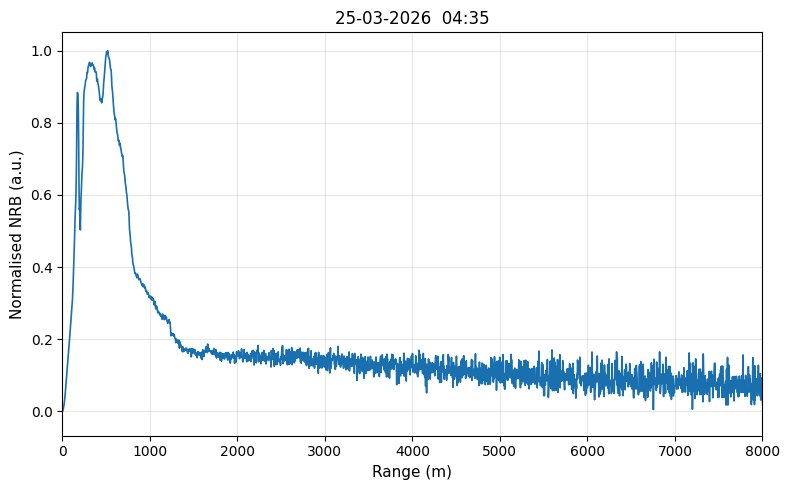

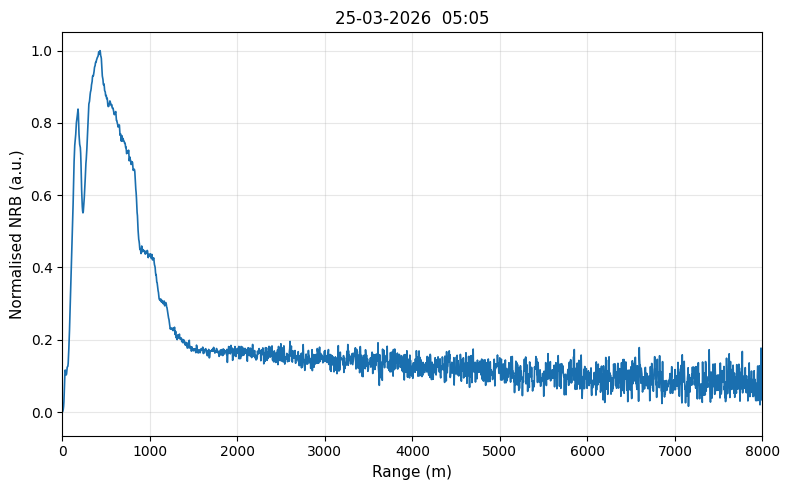

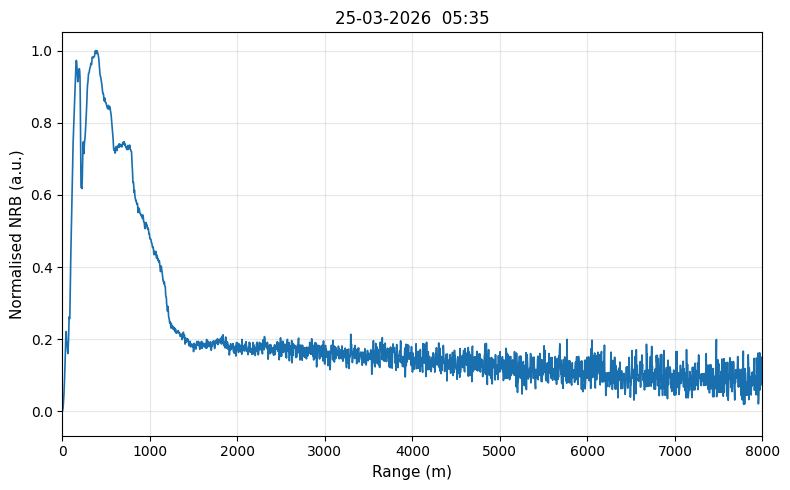

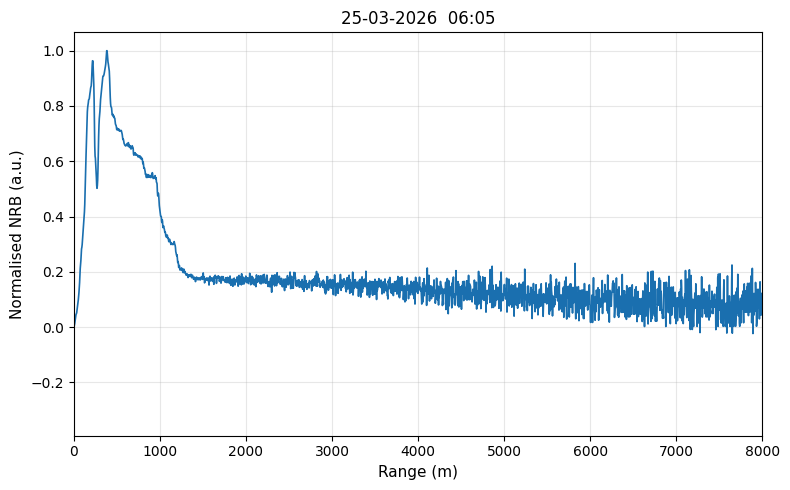

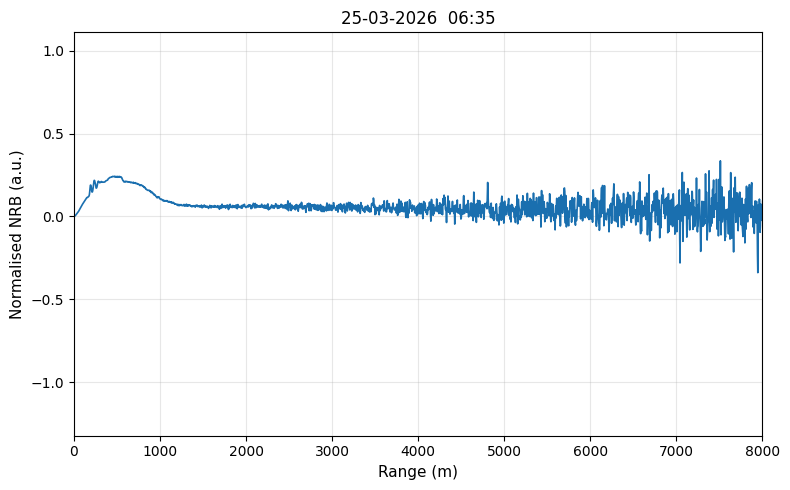

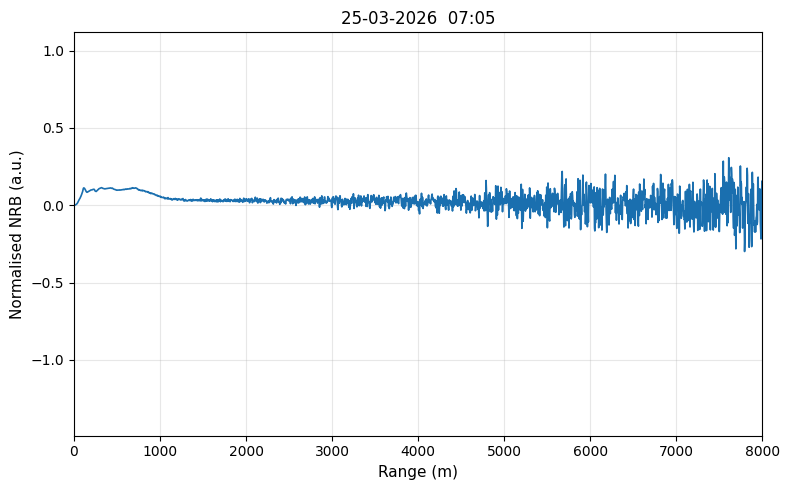

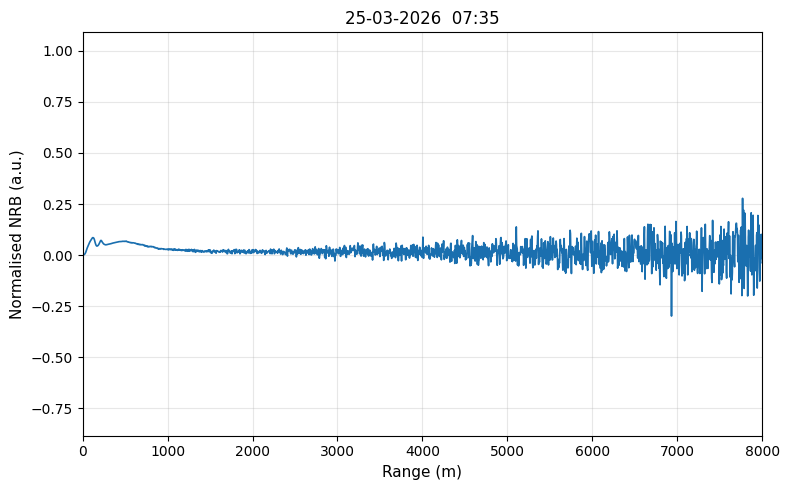

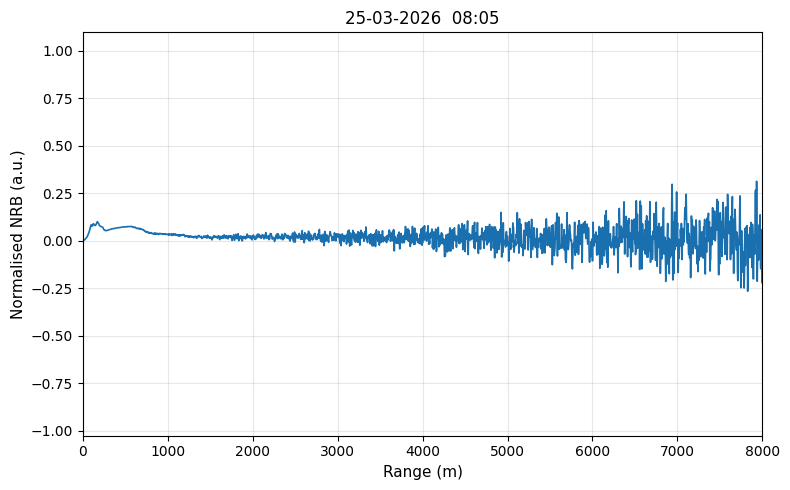

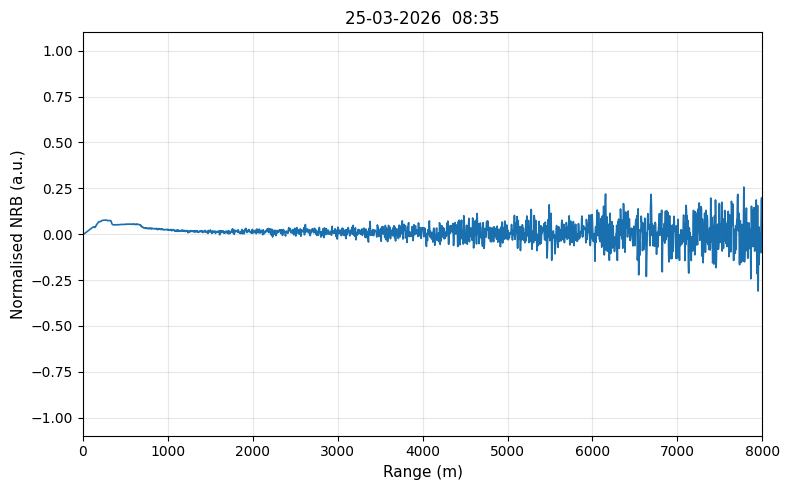

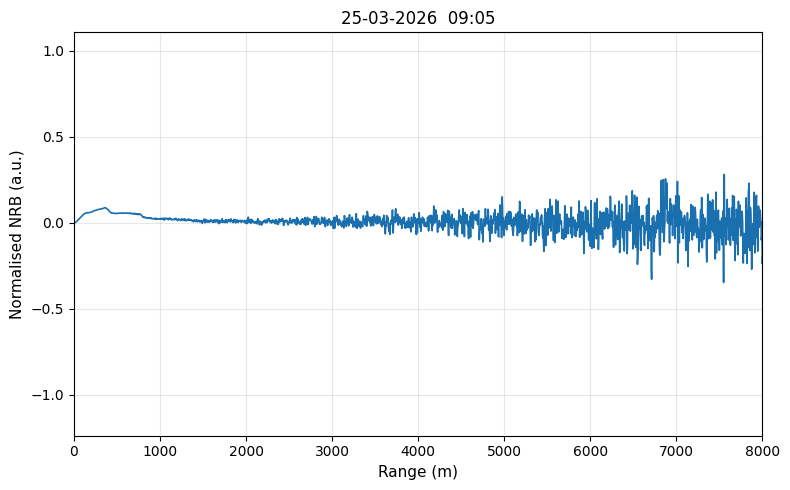

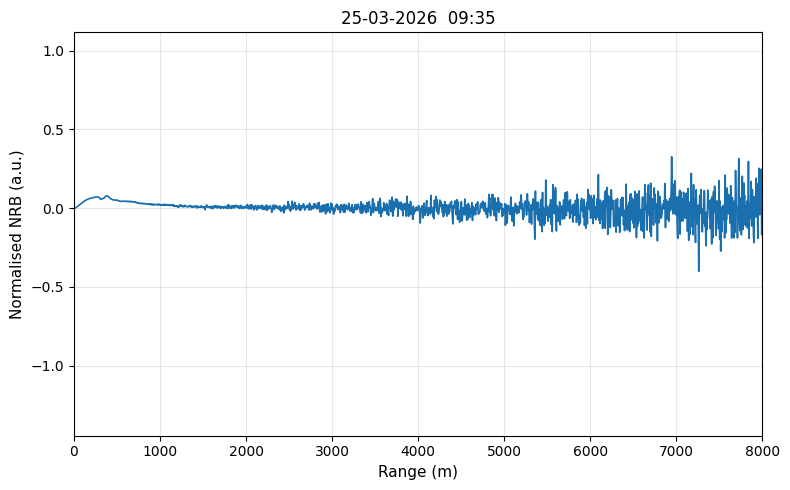

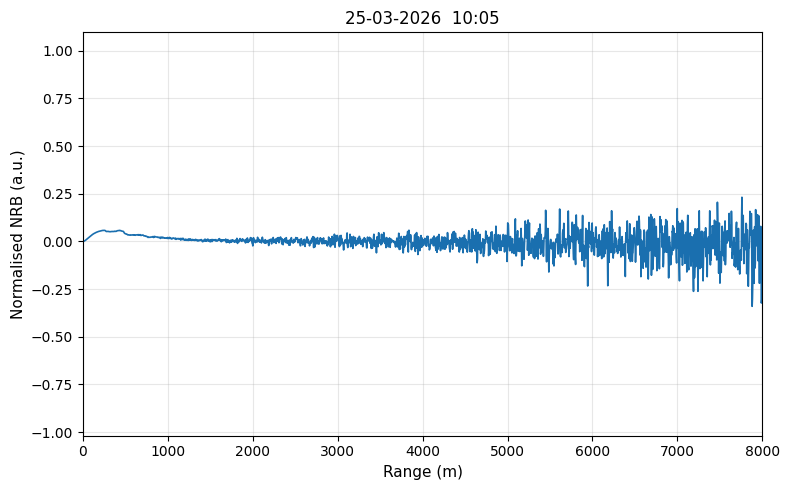

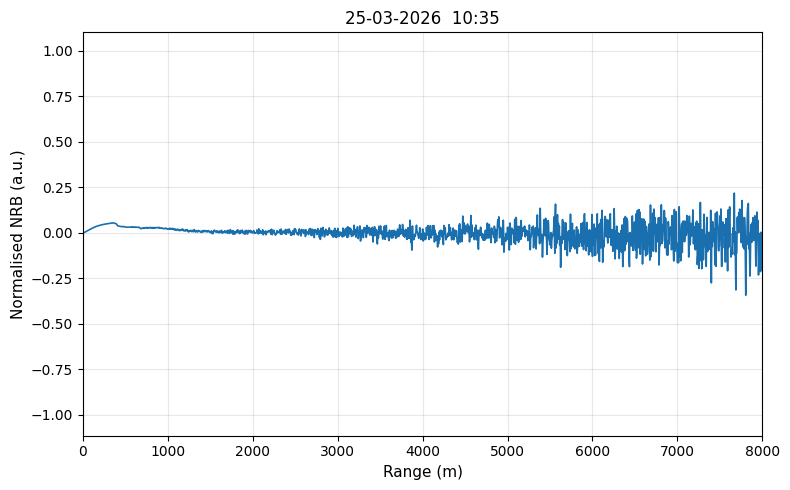

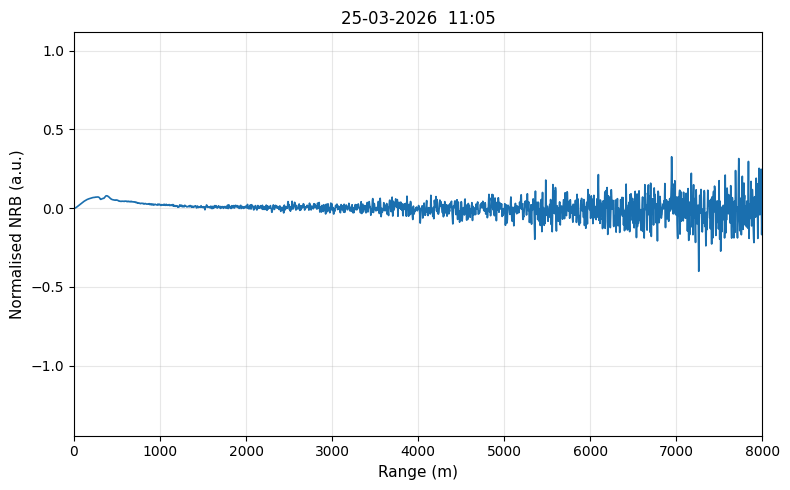

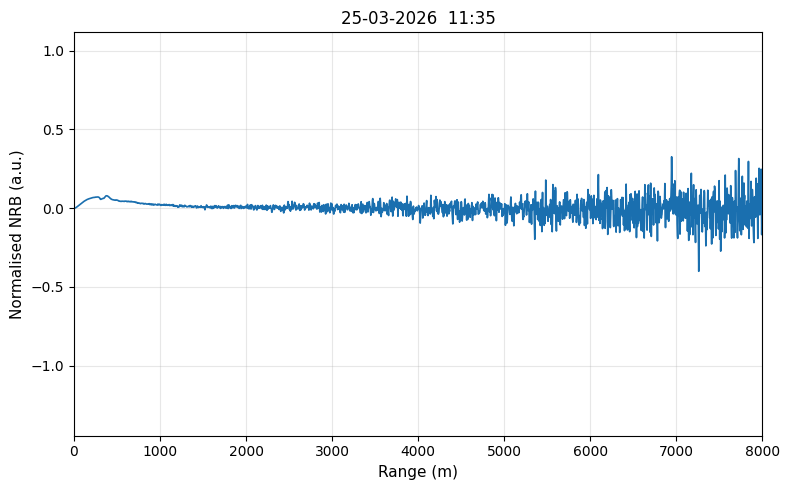

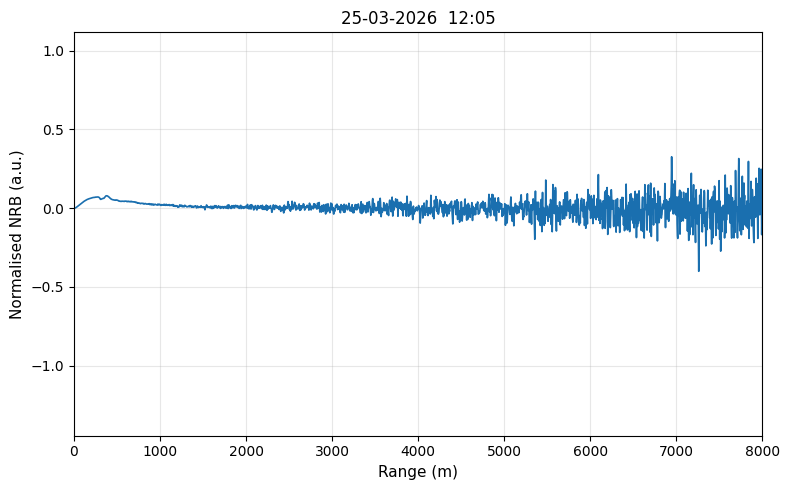

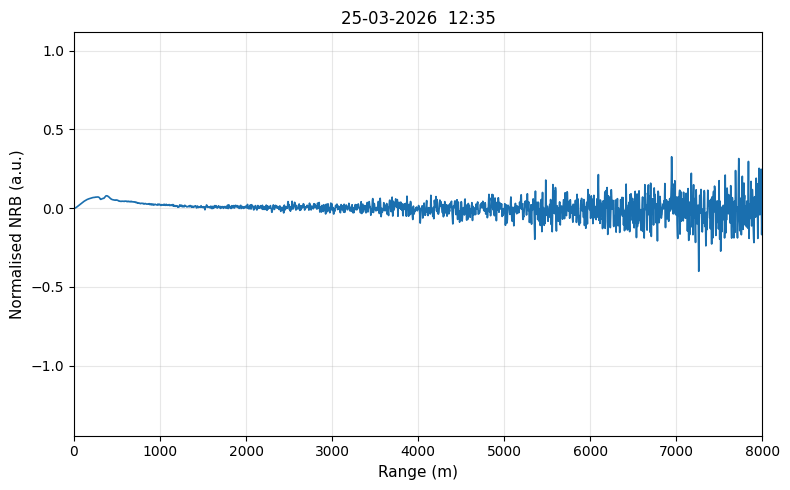

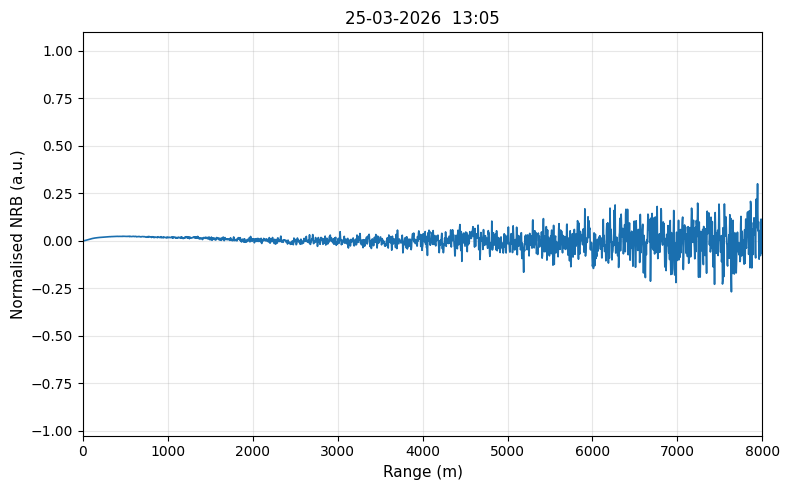

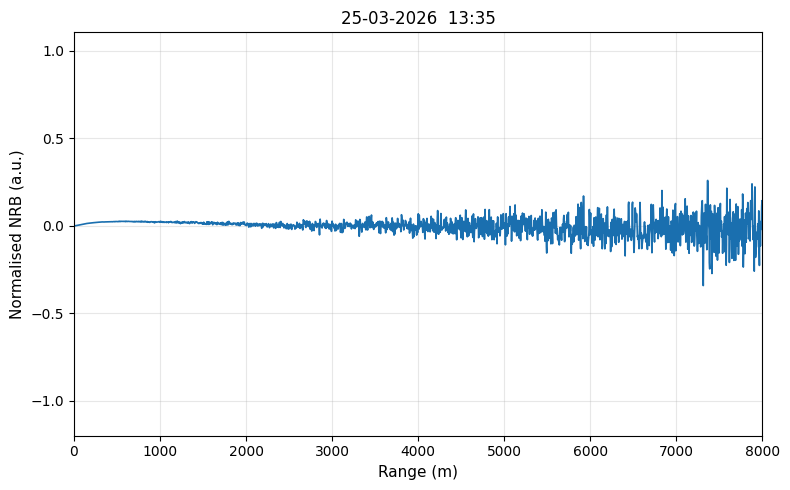

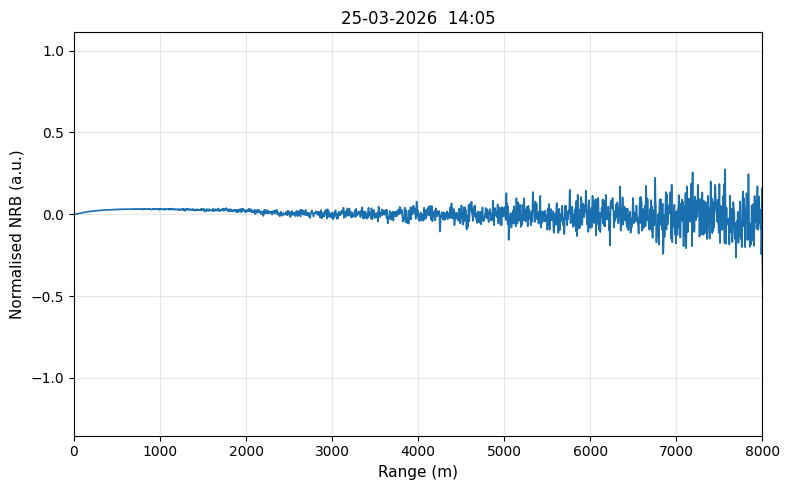

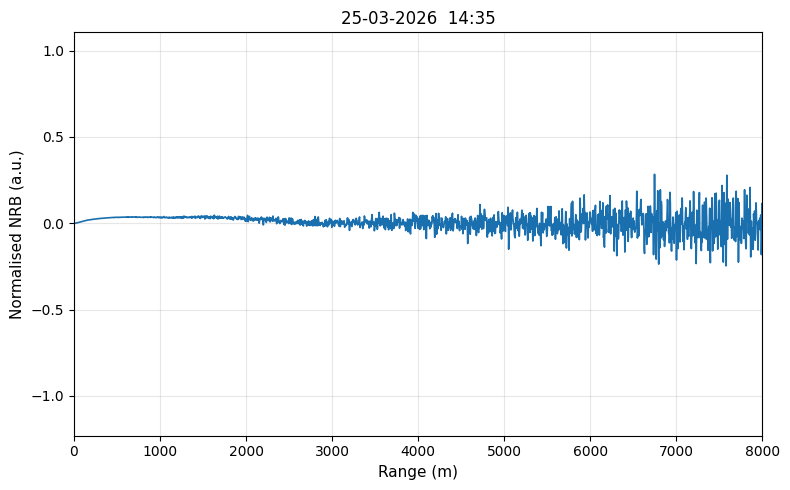

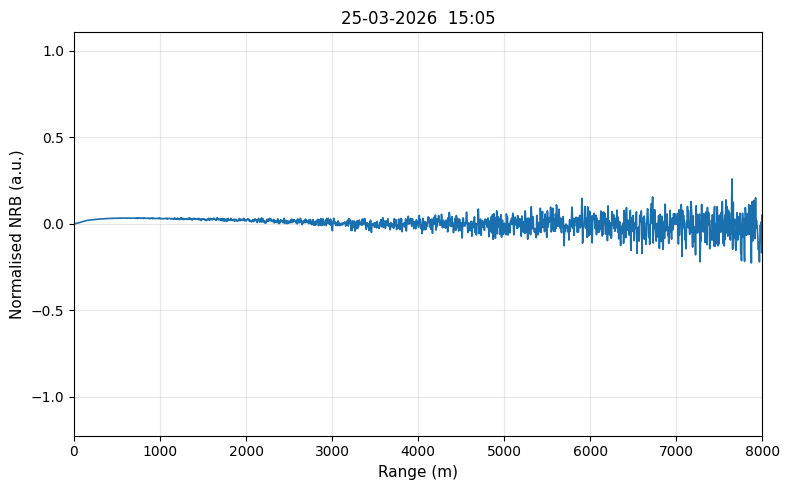

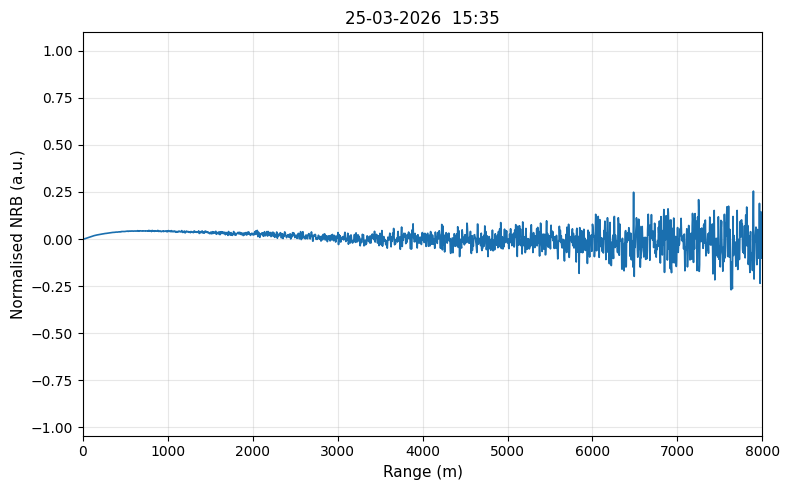

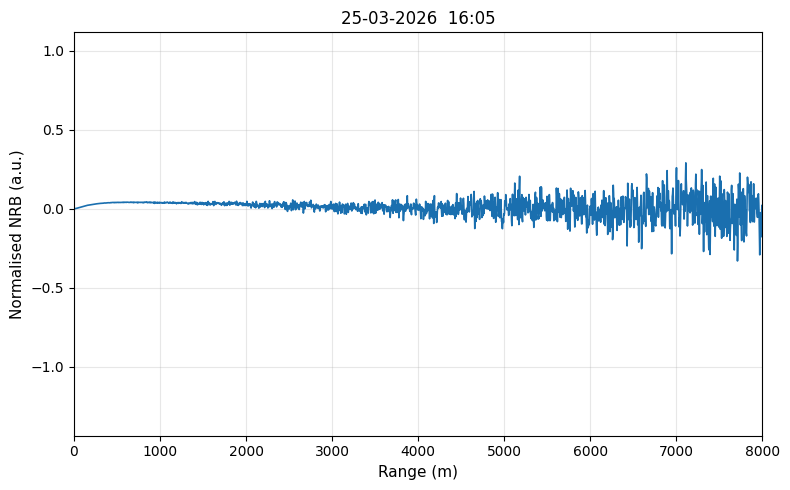

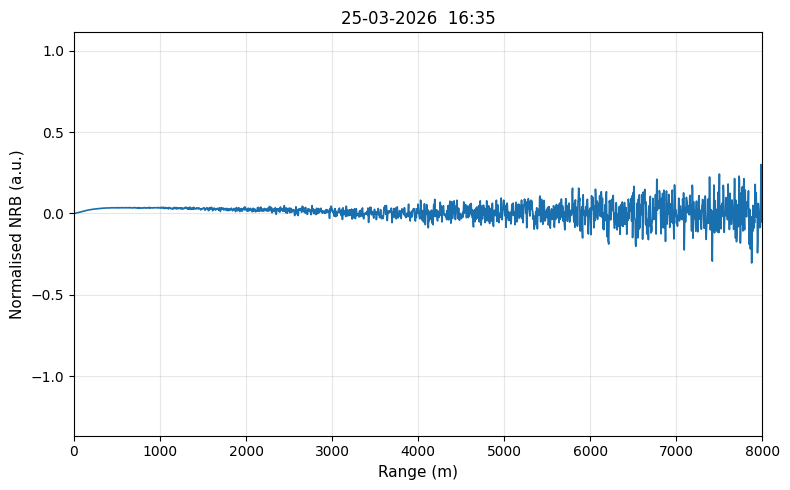

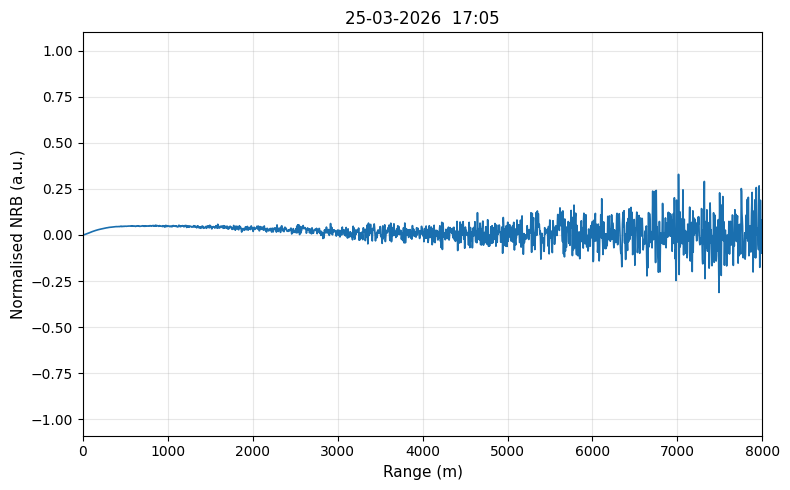

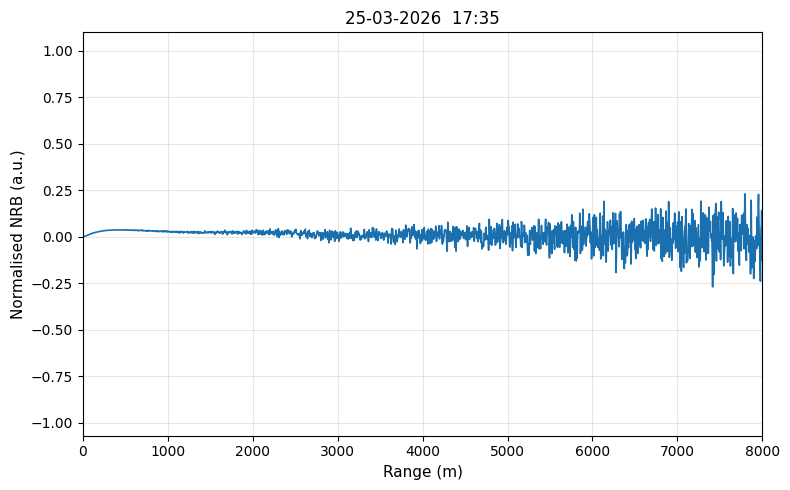

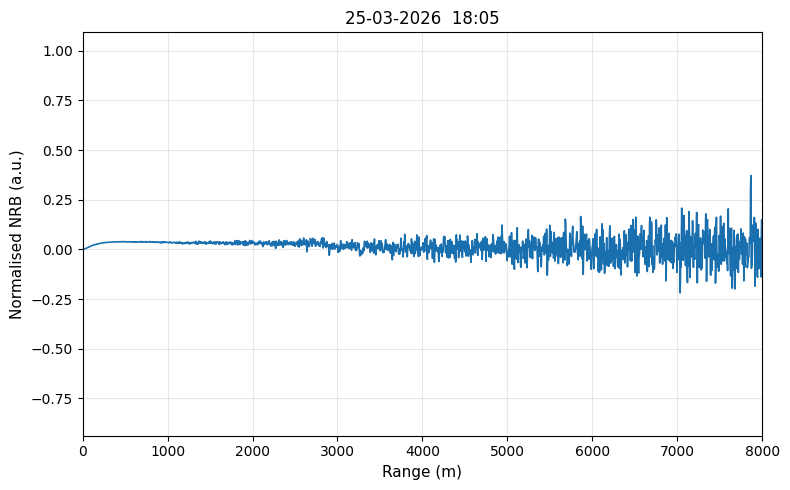

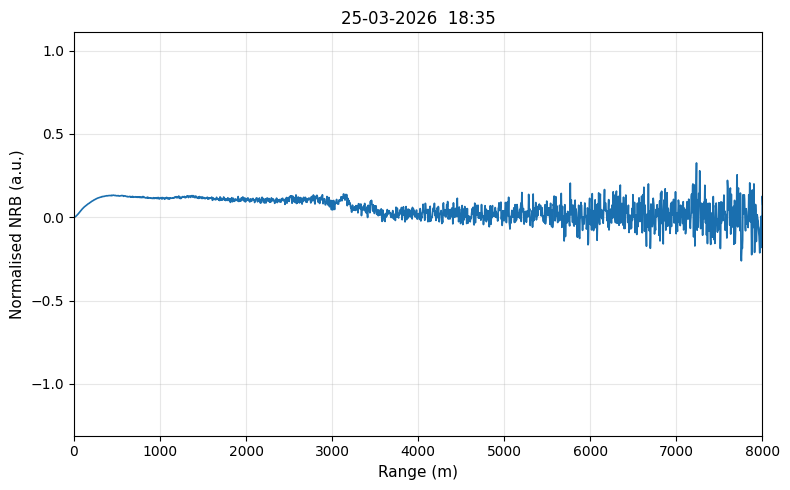

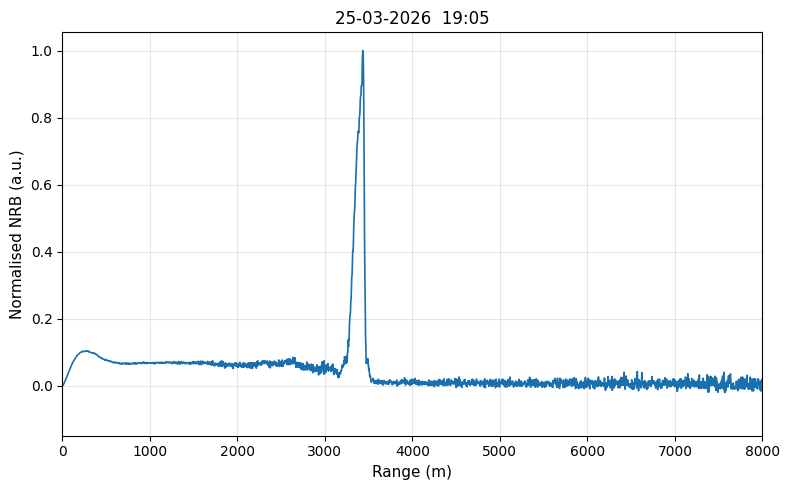

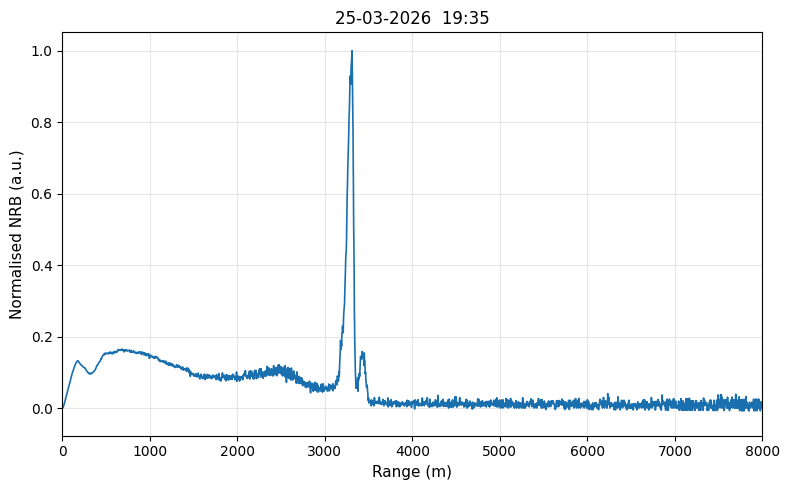

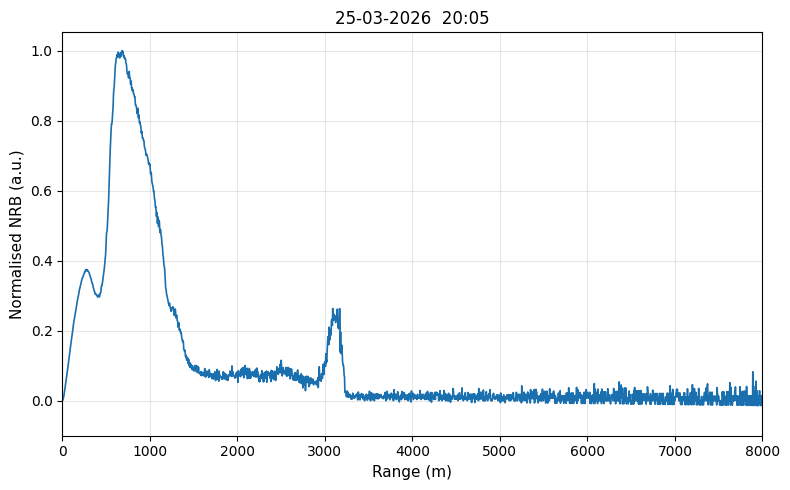

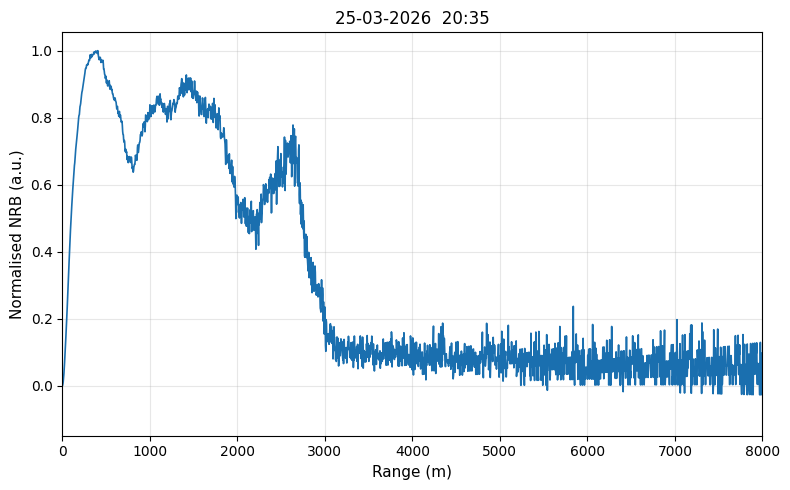

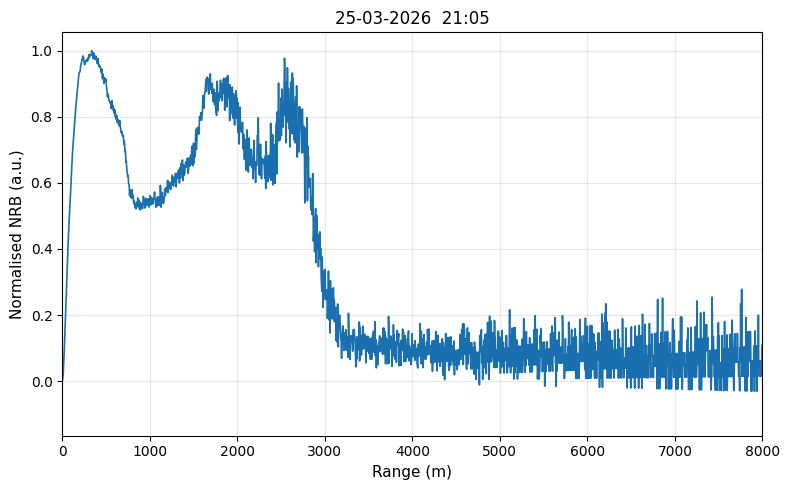

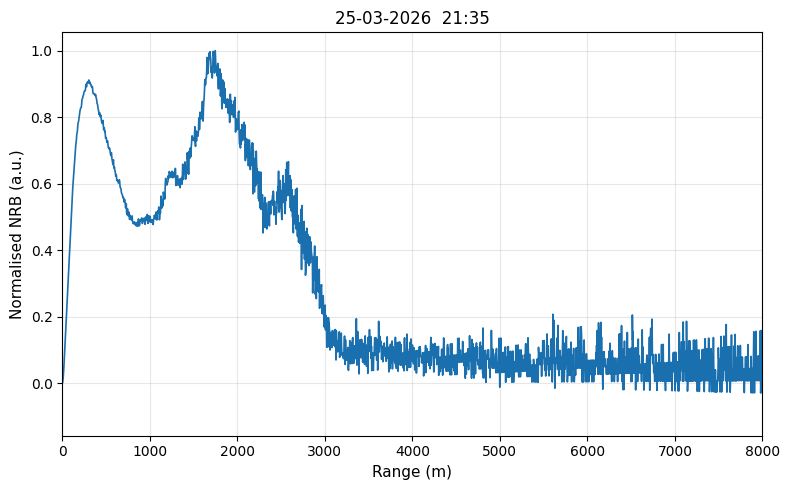

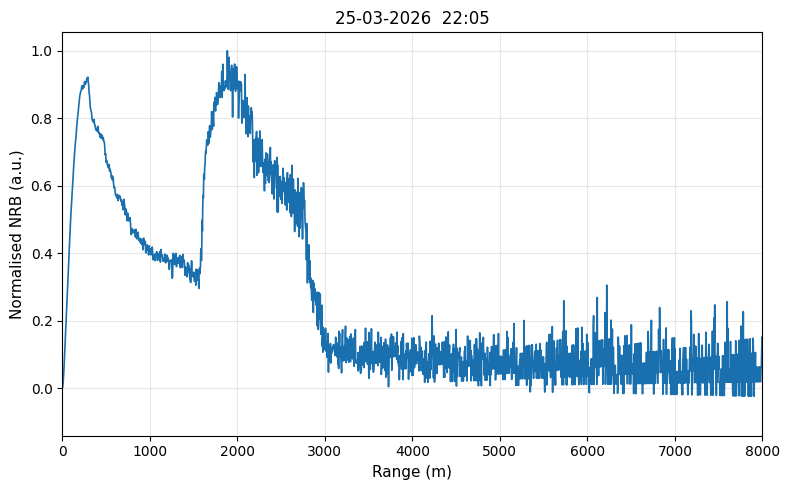

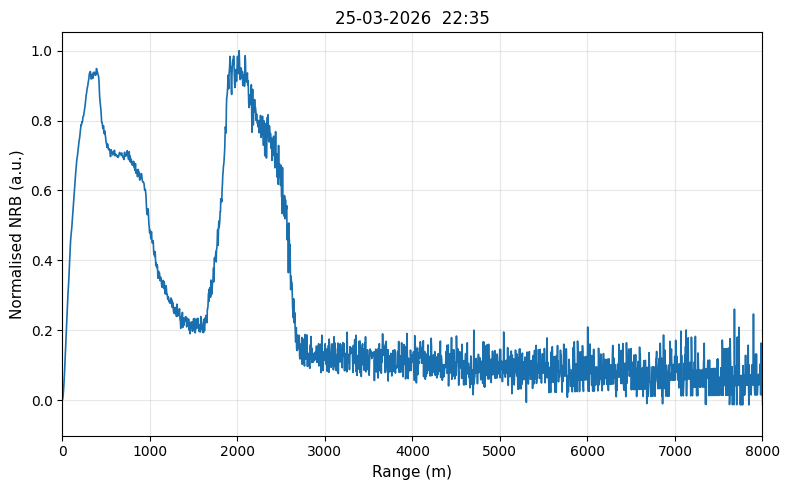

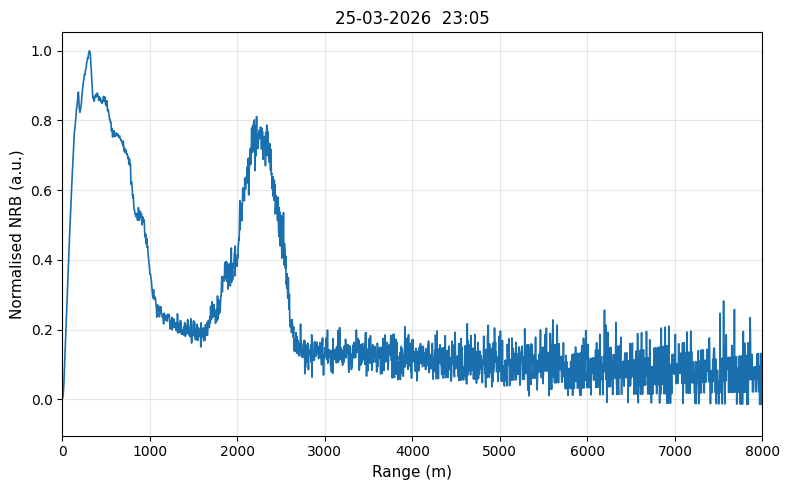

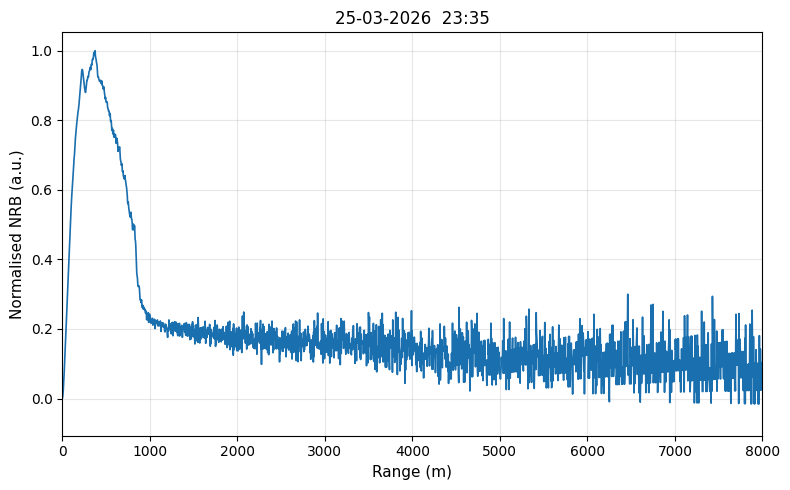

✅ Saved 48 profile plots → OutputPictCSV/CurtainPlots/profiles/25-03-2026

📅 26-03-2026: plotting 48 profiles


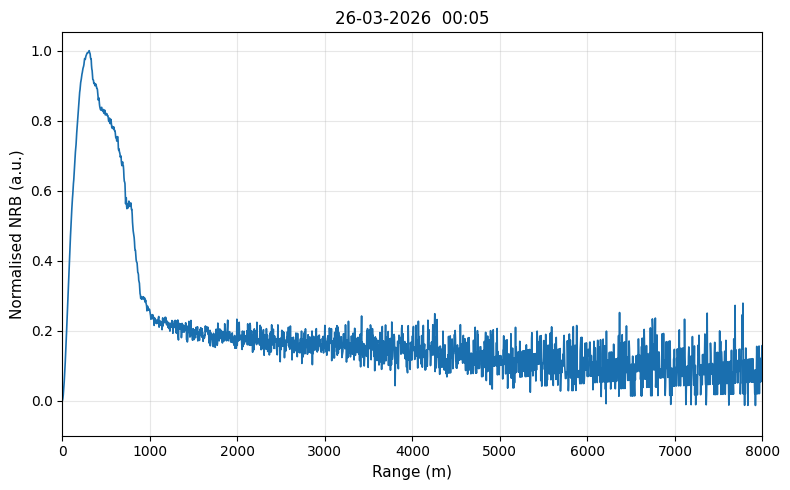

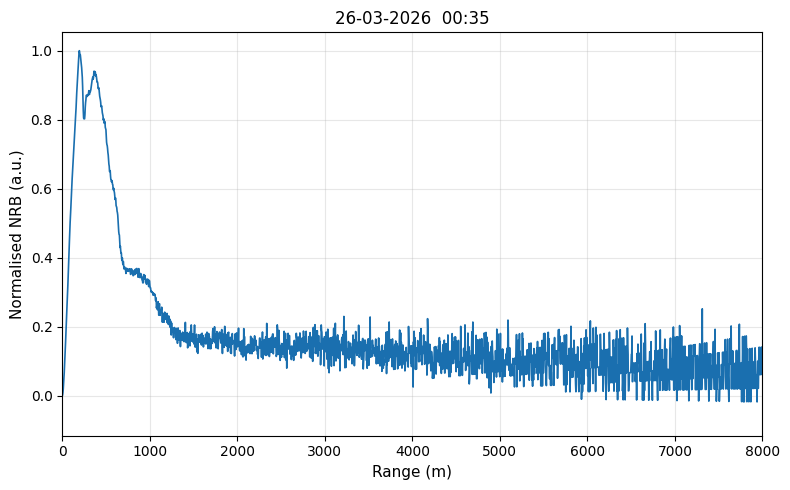

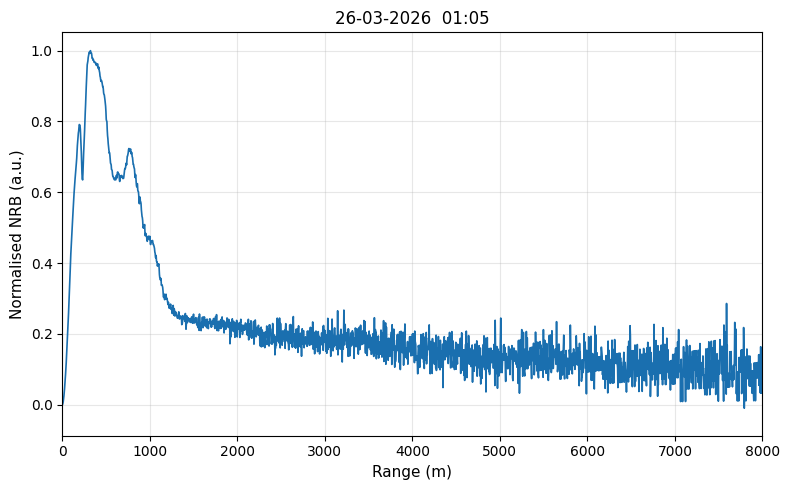

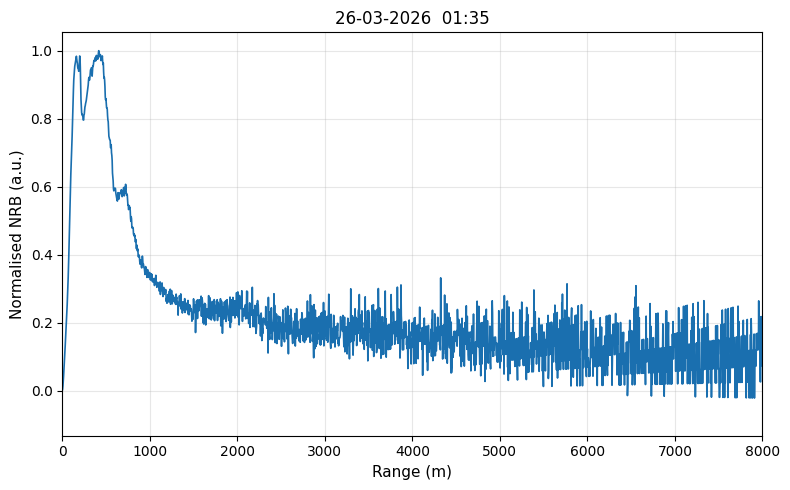

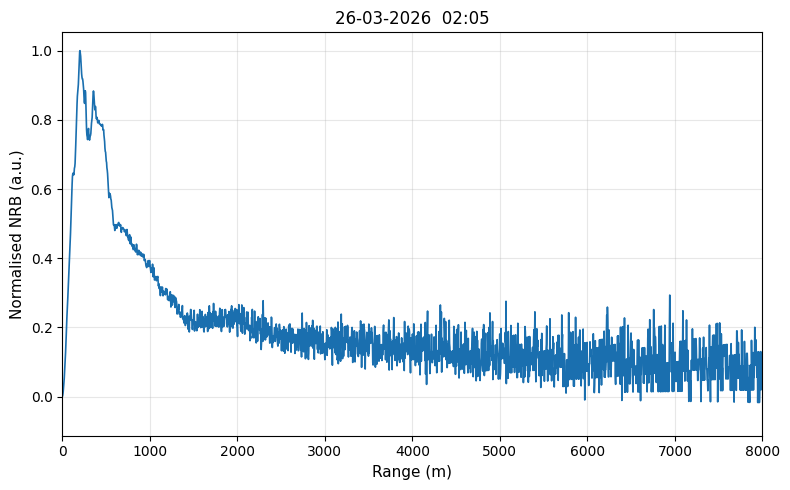

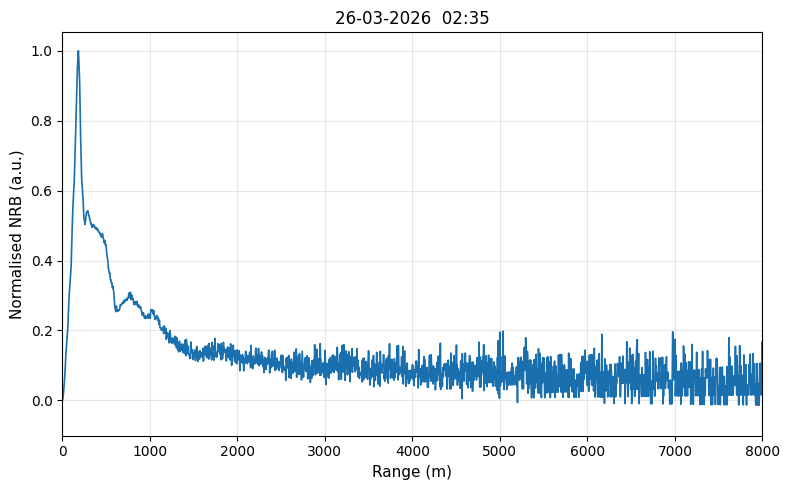

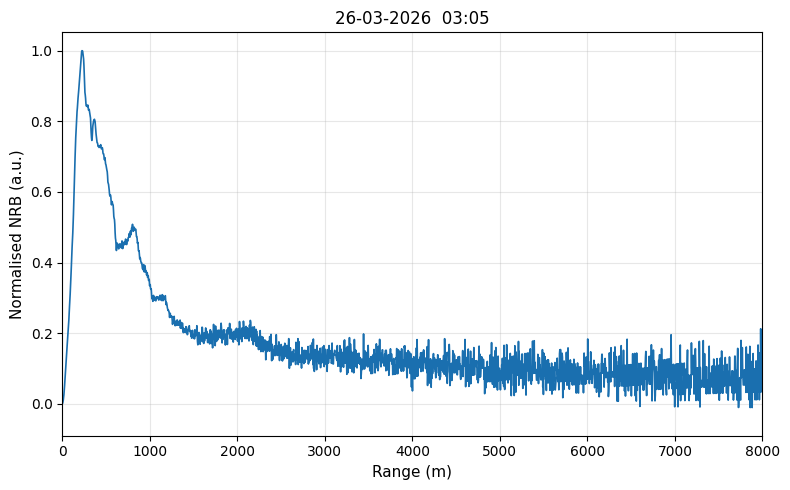

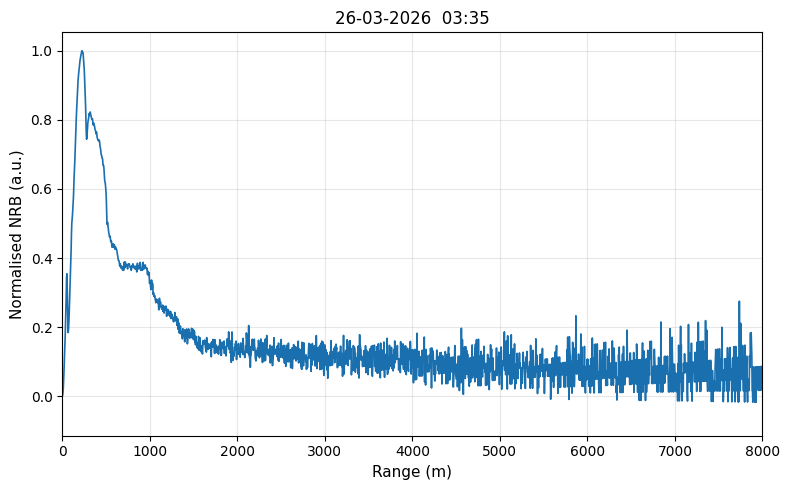

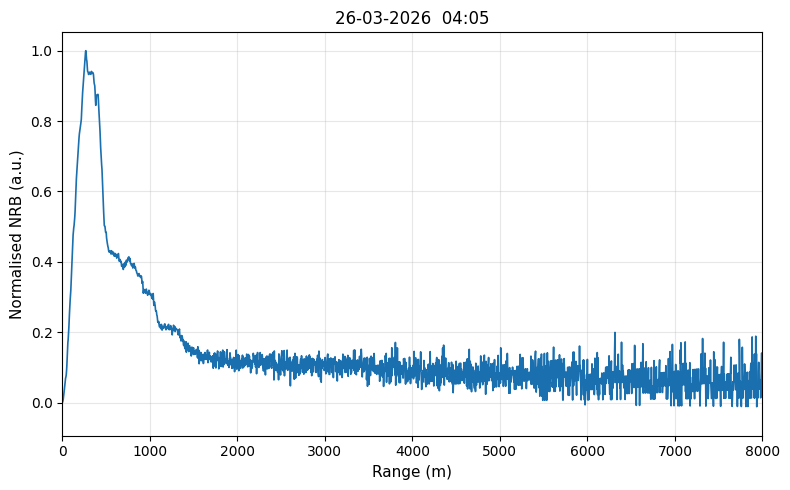

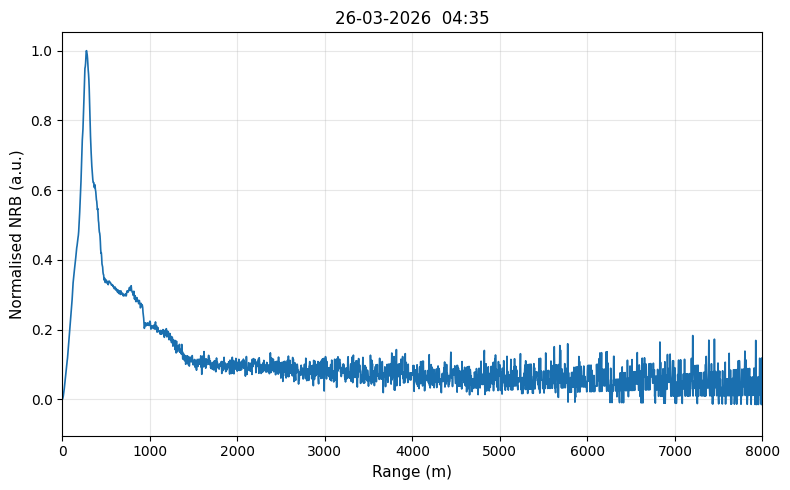

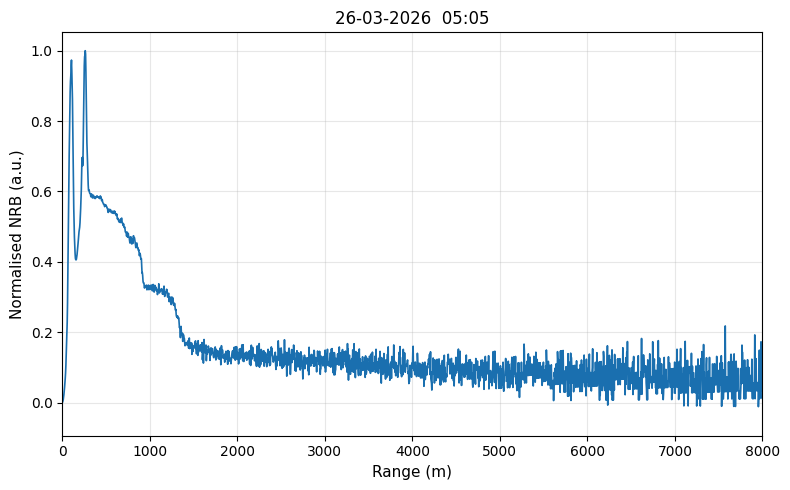

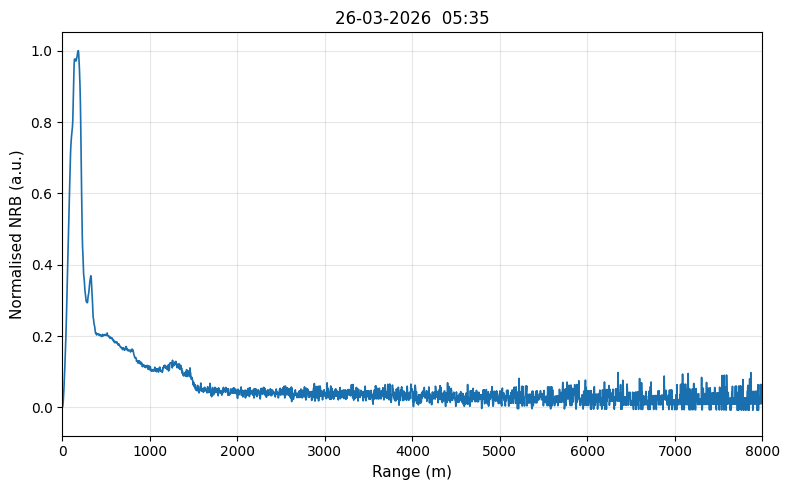

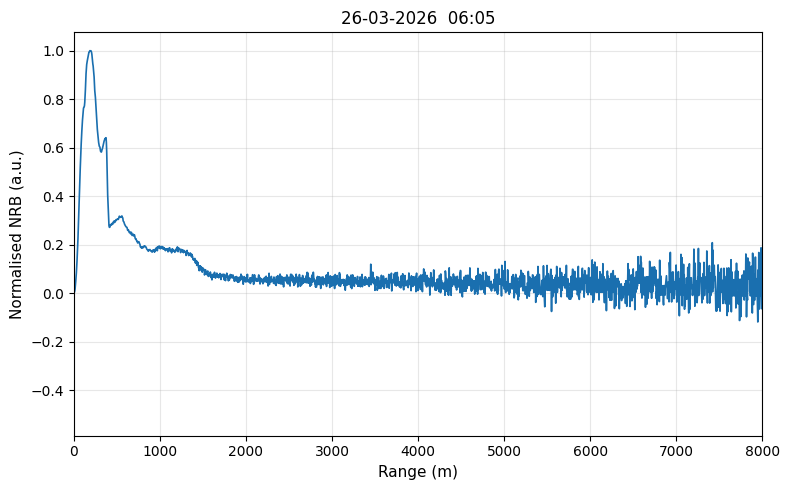

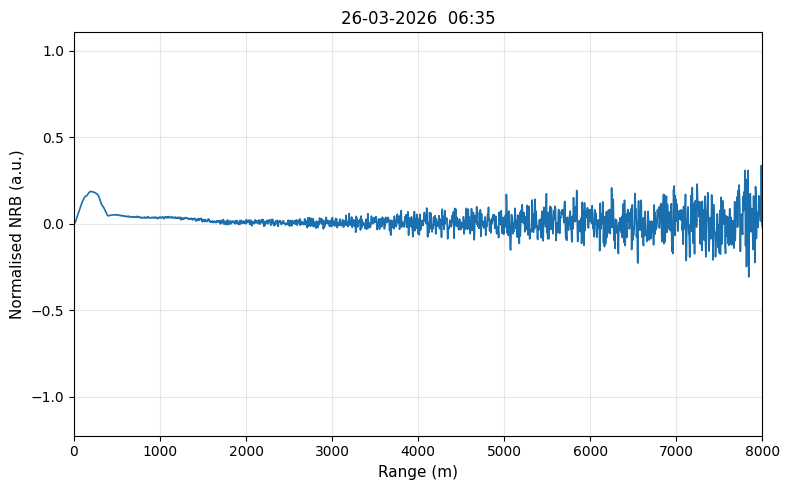

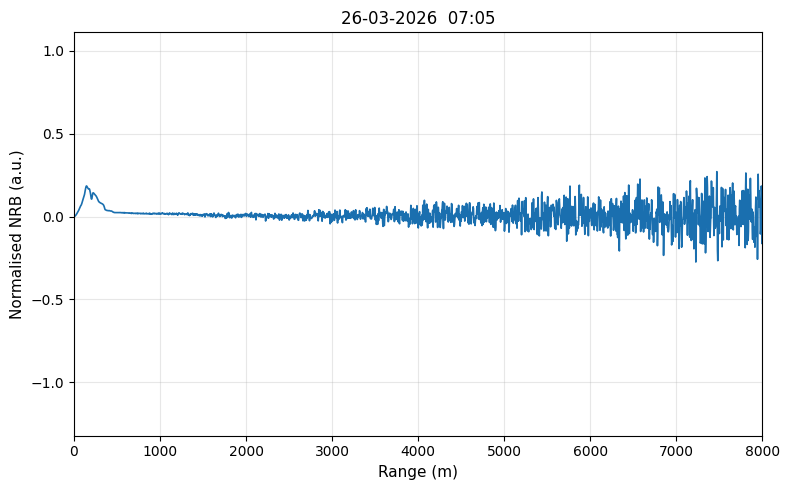

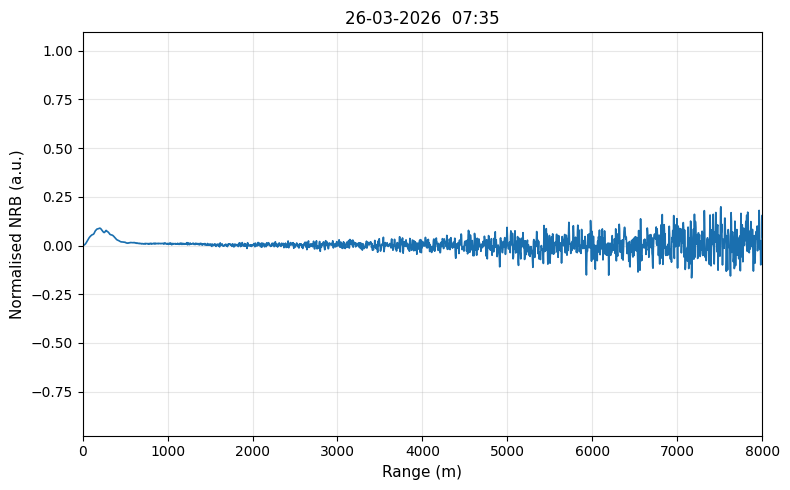

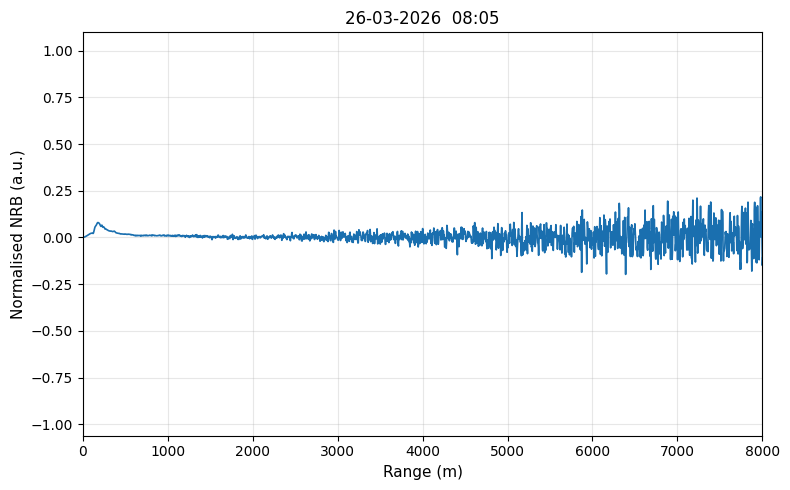

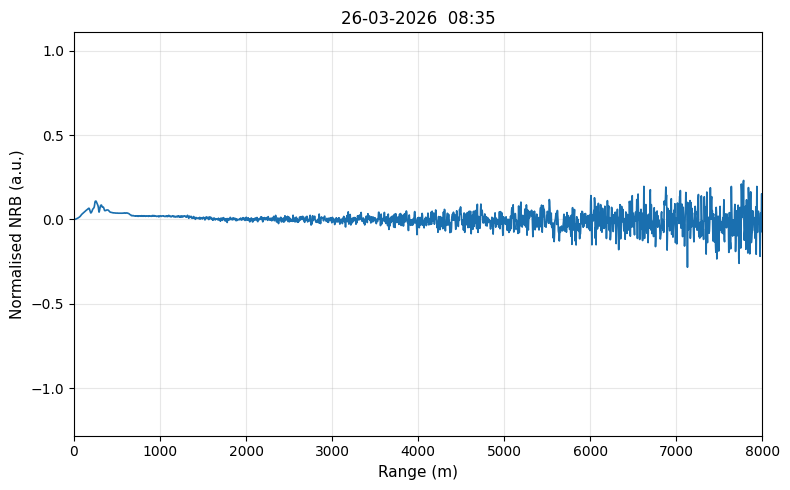

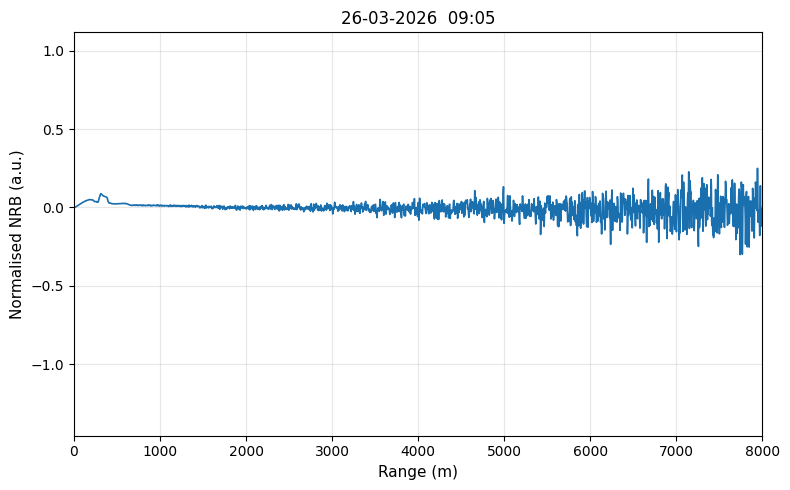

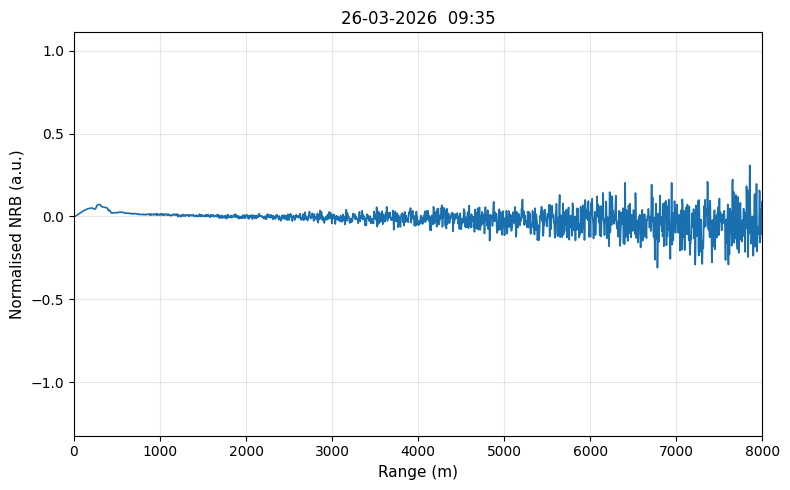

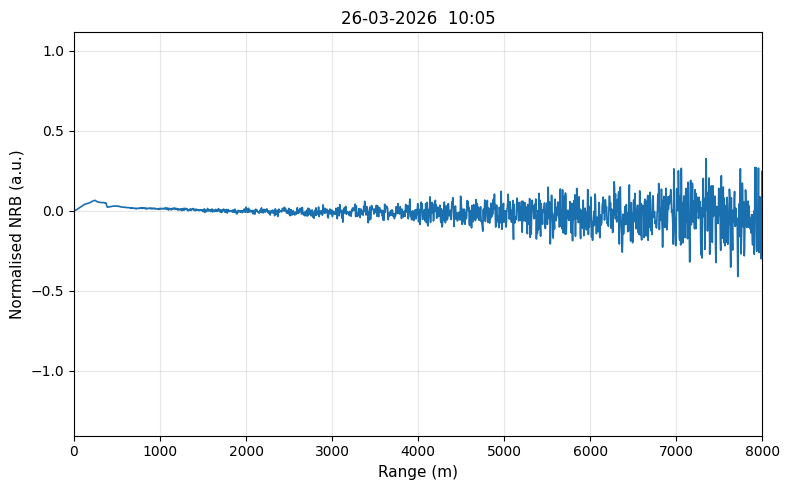

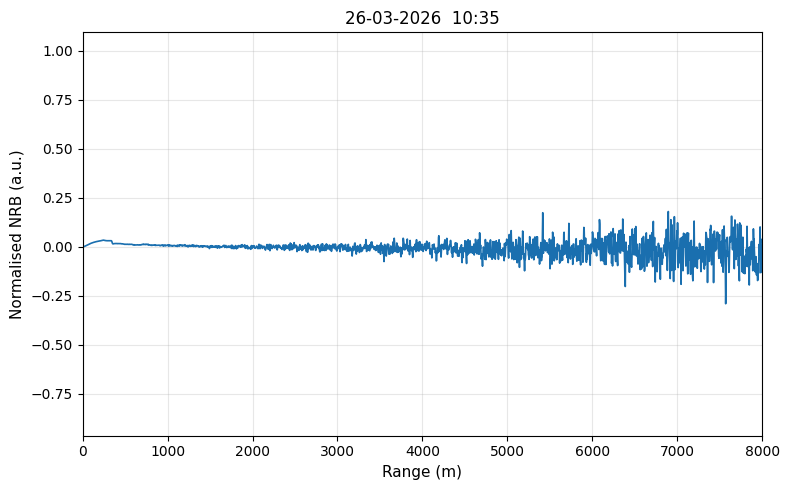

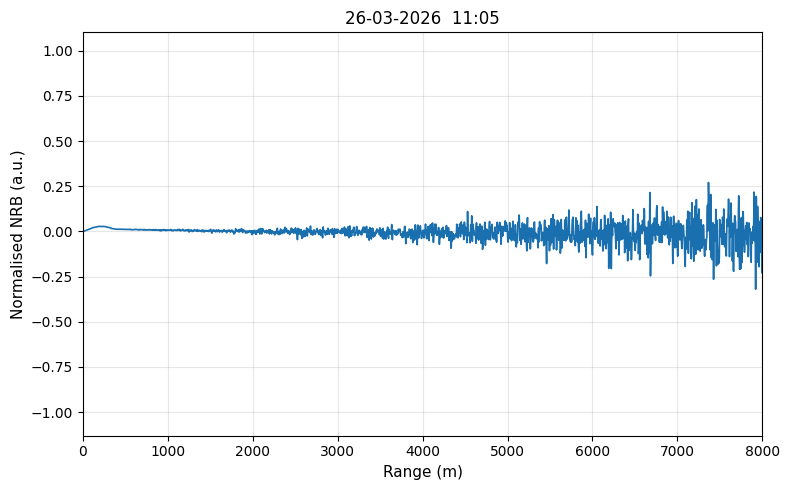

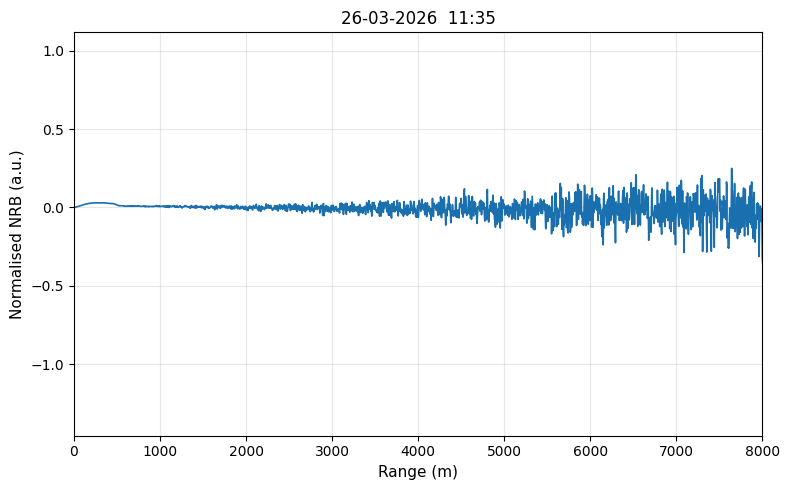

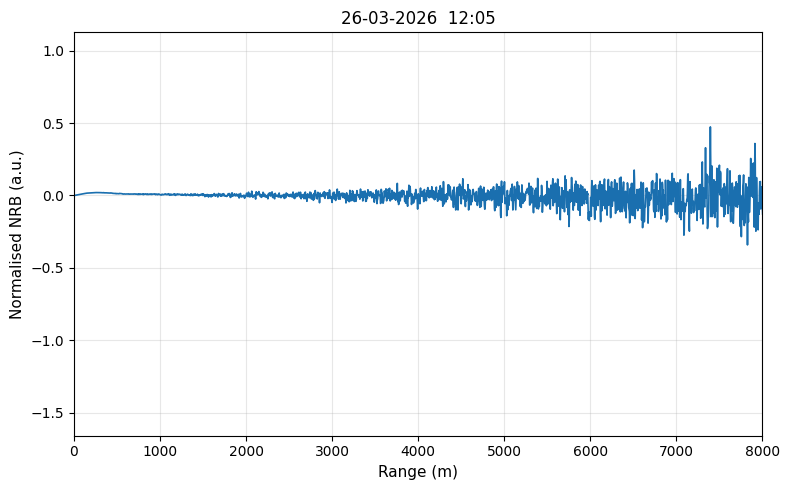

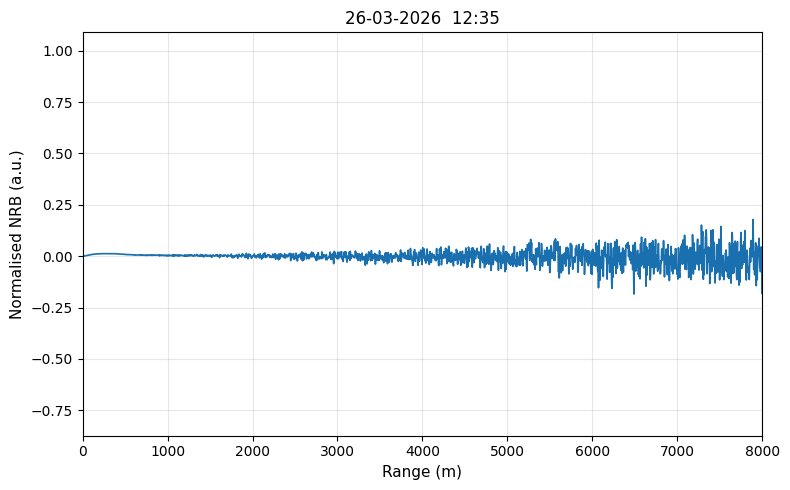

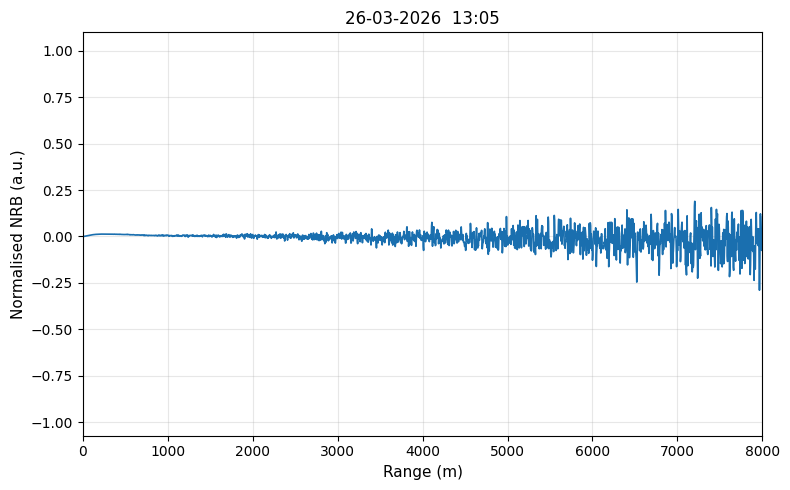

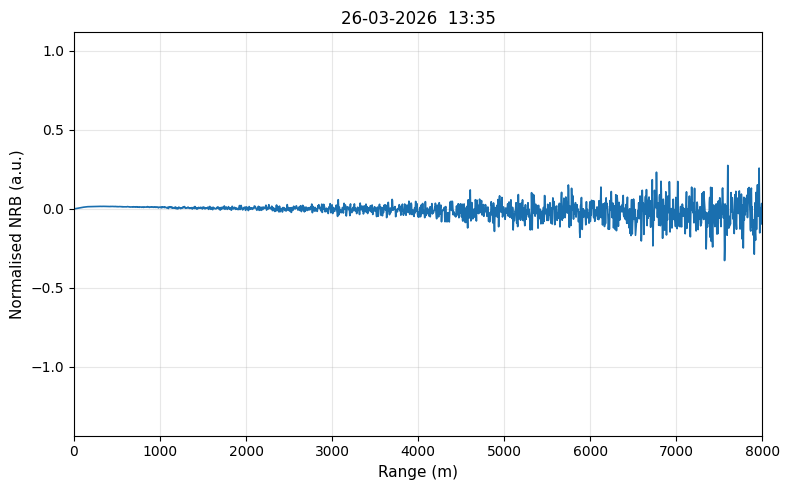

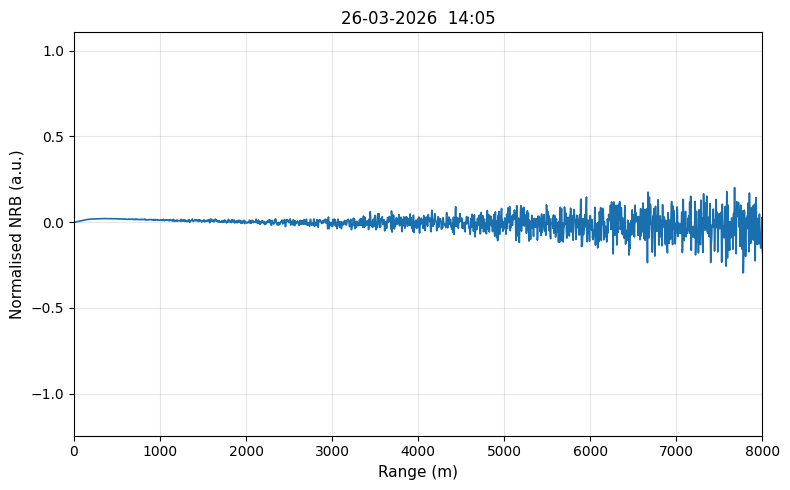

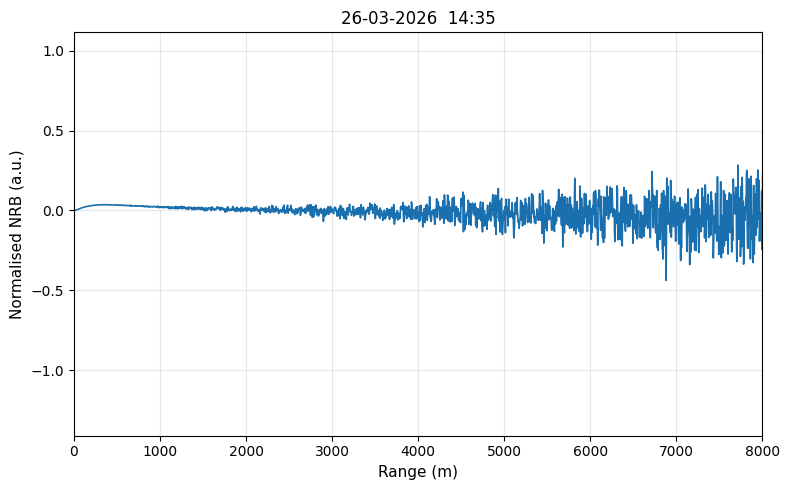

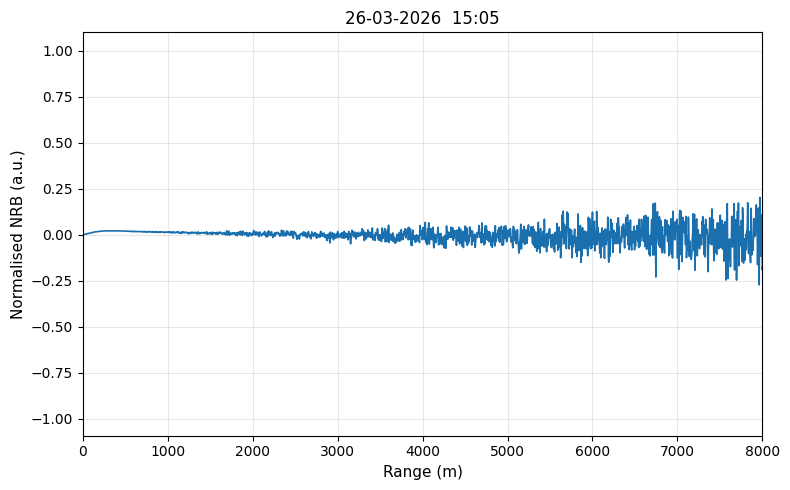

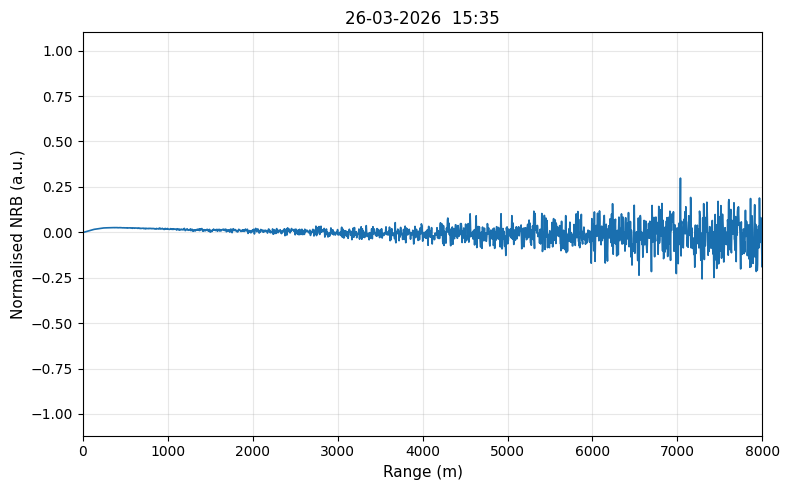

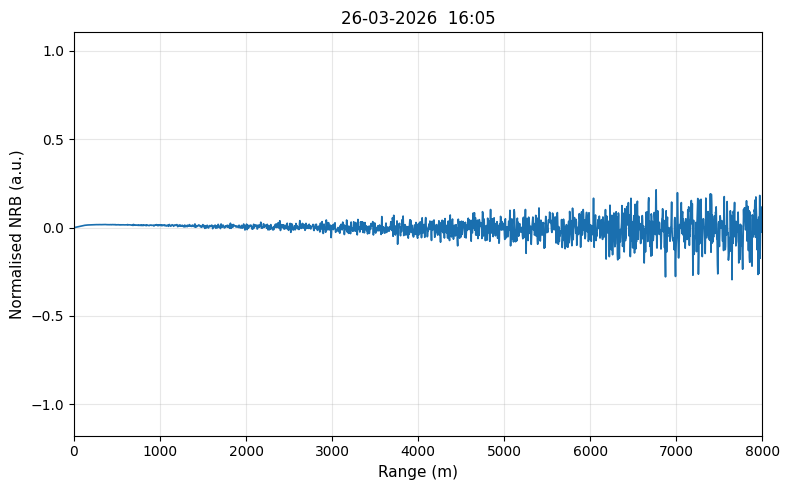

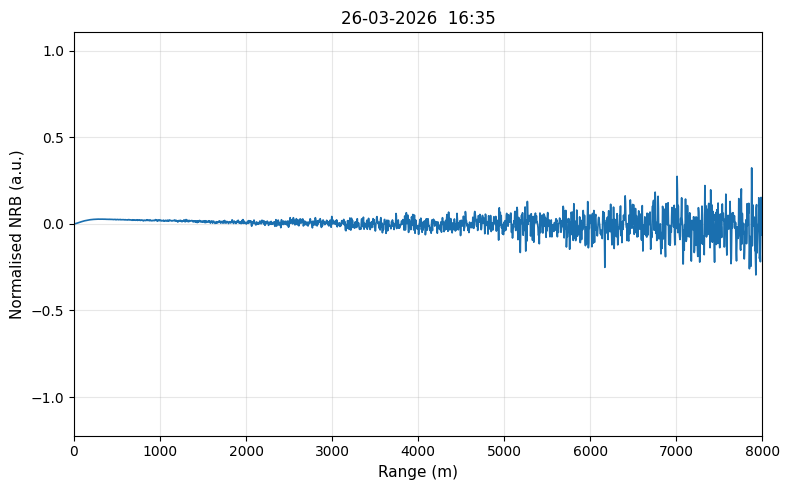

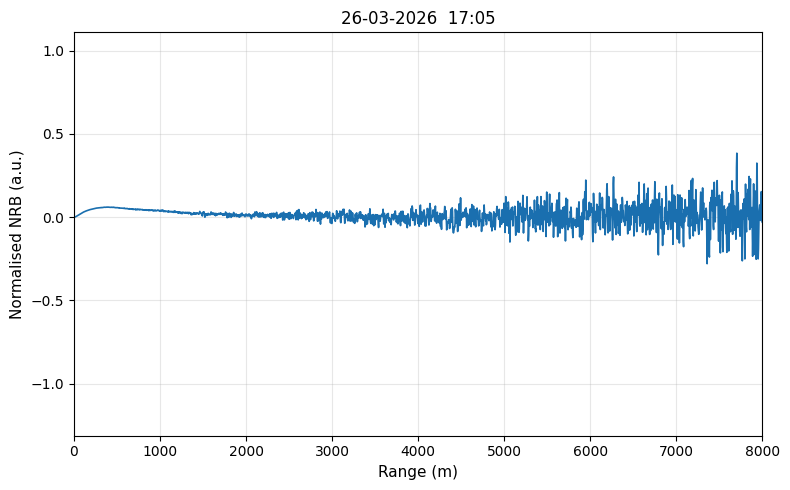

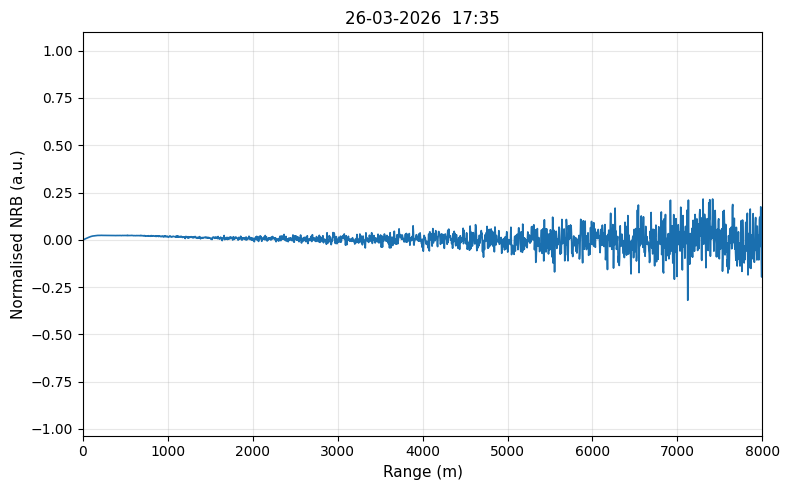

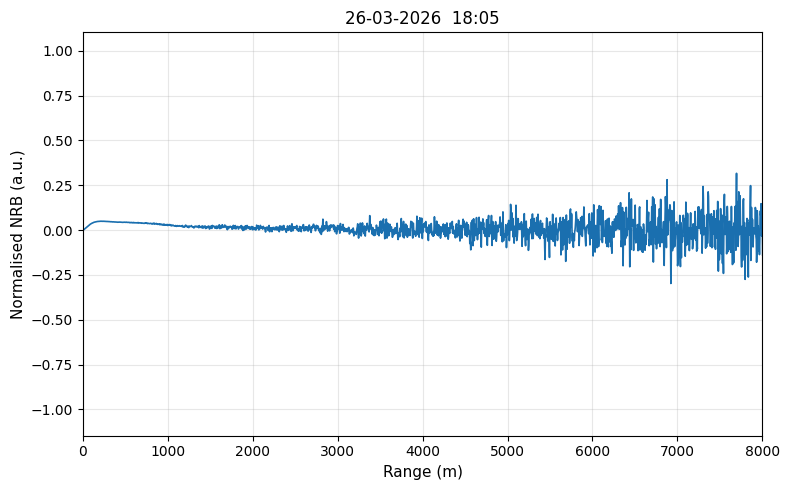

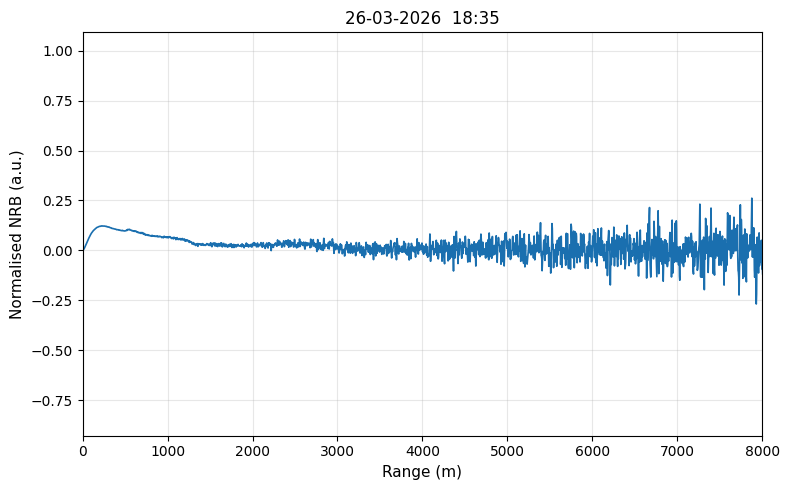

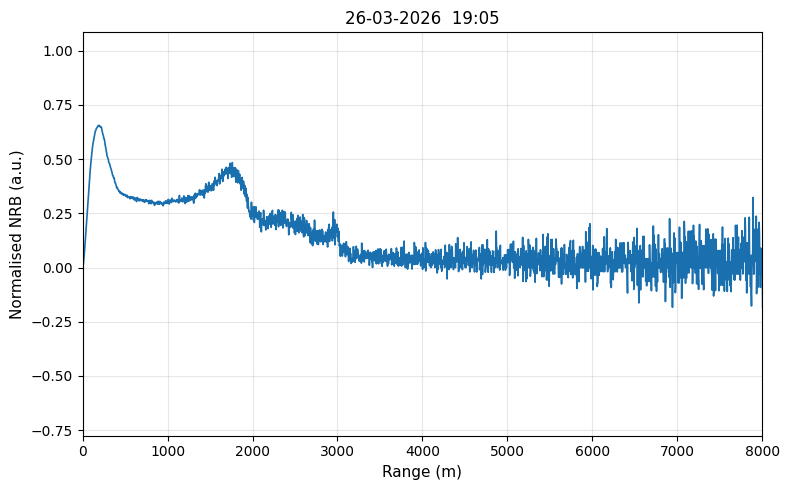

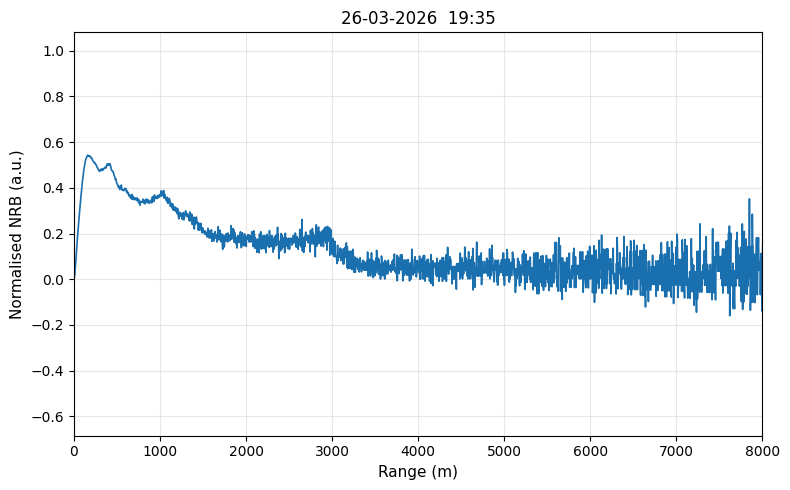

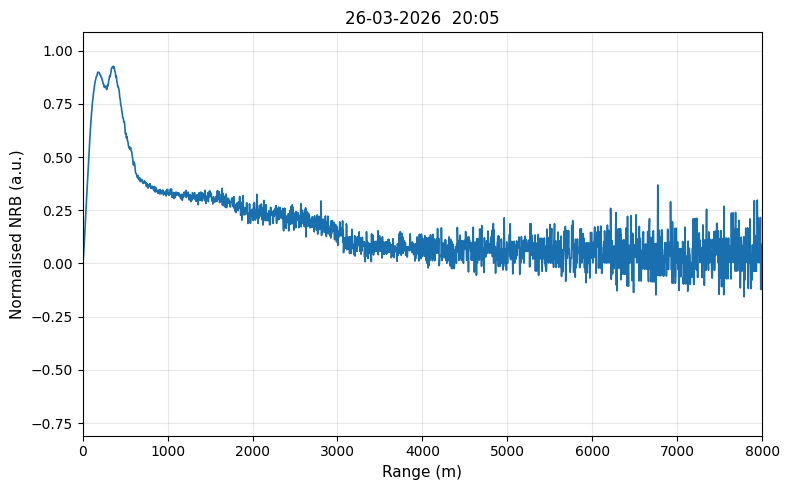

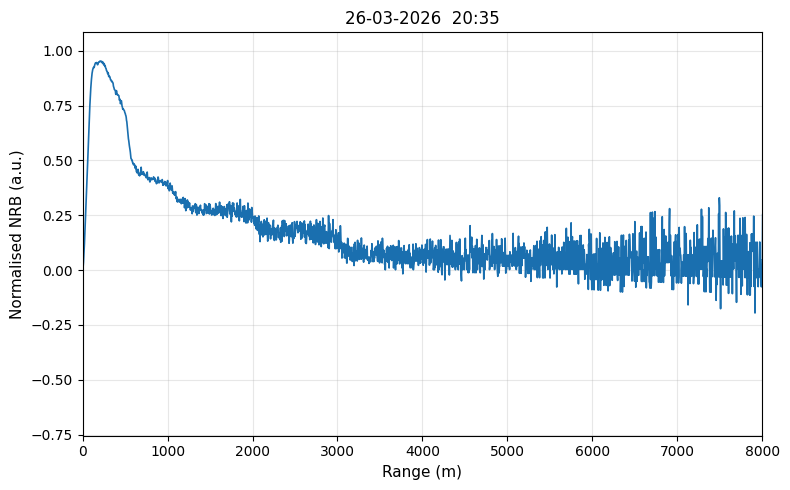

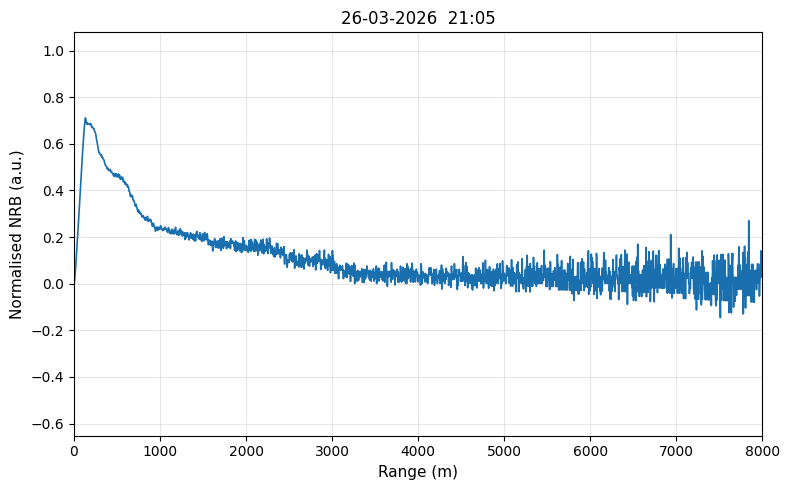

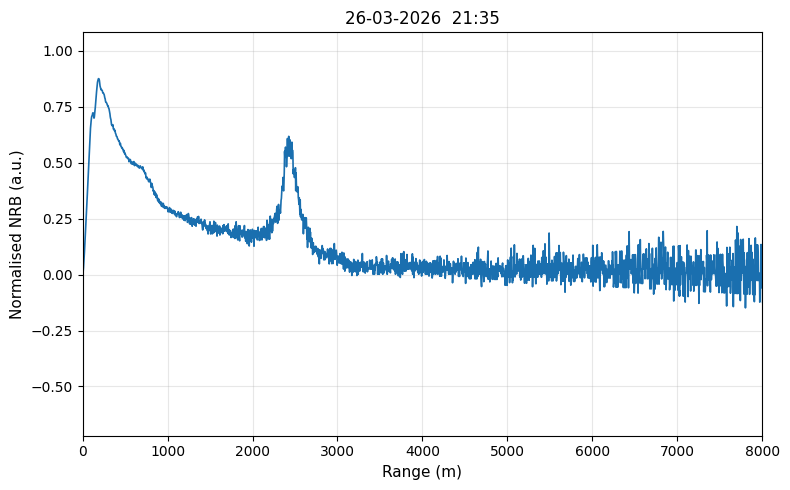

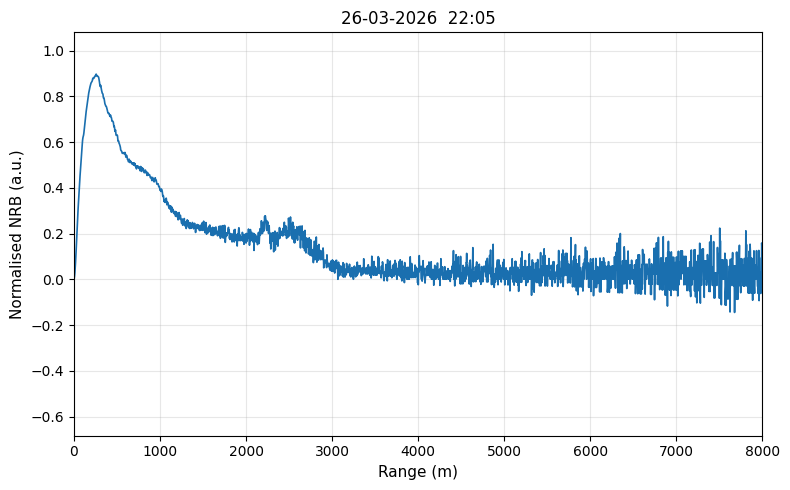

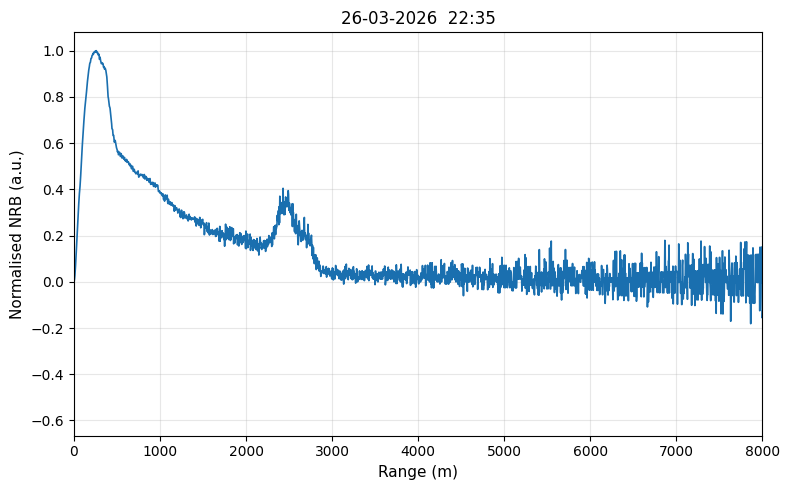

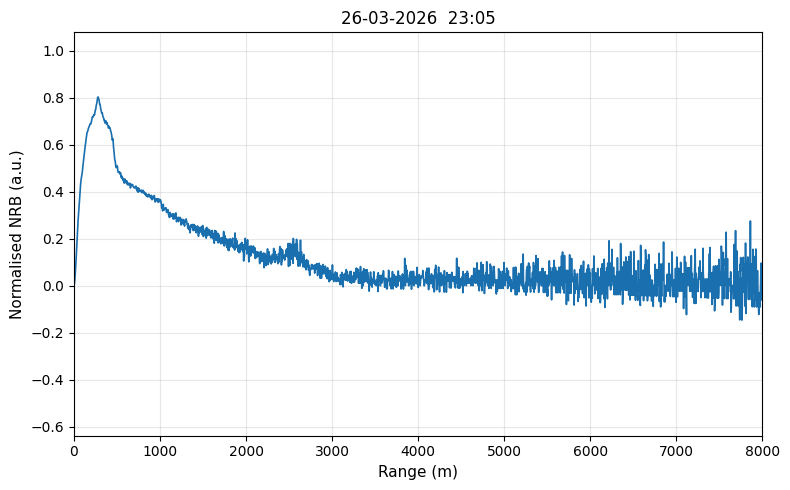

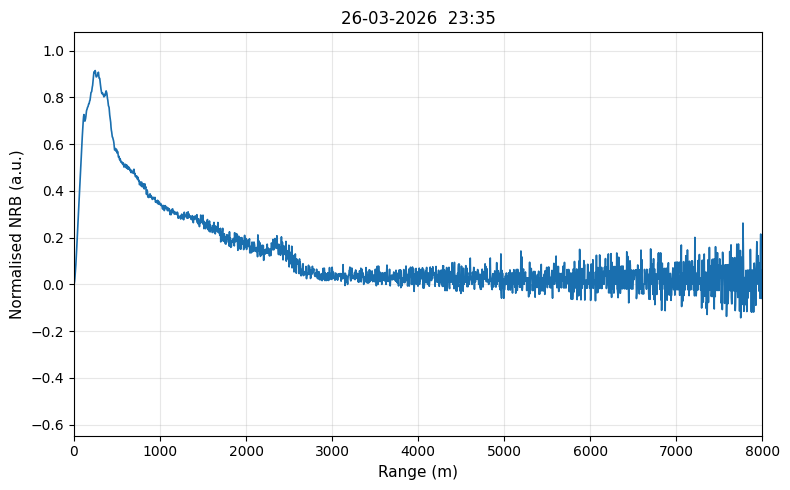

✅ Saved 48 profile plots → OutputPictCSV/CurtainPlots/profiles/26-03-2026


In [28]:
for day in DAYS:
    if day not in day_dfs_signal:
        print(f"[SKIP] {day}")
        continue

    df_day = day_dfs_signal[day]
    time_tags = sorted(df_day["time_tag"].unique())

    profile_dir = Path(SAVE_DIR) / "profiles" / day
    profile_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n📅 {day}: plotting {len(time_tags)} profiles")

    for tt in time_tags:
        df_t = df_day[df_day["time_tag"] == tt]

        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(df_t["range_m"], df_t["range2_norm"],
                color="#1a6faf", linewidth=1.2)

        ax.set_xlabel("Range (m)", fontsize=11)
        ax.set_ylabel("Normalised NRB (a.u.)", fontsize=11)
        ax.set_title(f"{day}  {tt.replace('.', ':')}", fontsize=12)
        ax.set_xlim(0, 8000)
        ax.grid(True, alpha=0.3)

        fig.tight_layout()
        fig.savefig(profile_dir / f"{tt.replace('.', '')}.png", dpi=150, bbox_inches="tight")
        # plt.close(fig)
        plt.show()

    print(f"✅ Saved {len(time_tags)} profile plots → {profile_dir}")